# Grupo 2:
## Integrantes: Bruno Fardella, Franco Valdebenito, Leticia Zapata

# Contexto y Objetivo

La bancarrota afecta a empresas, empleados y la estabilidad financiera de un país. El Dataset que se encuentra en este [enlace](https://www.kaggle.com/datasets/stealthtechnologies/predict-bankruptcy-in-poland/data) contiene datos financieros usados para predecir la bancarrota en empresas polacas. Las compañías en bancarrota fueron analizadas en el período 2000-2012, mientras que las que siguen operantes fueron evaluadas entre el 2007 y el 2013.

El objetivo será cuantificar el riesgo de quiebre e identificar patrones y variables que influyen en este riesgo. Se desea determinar si es que una empresa quebrará o no acorde a su estado financieron en los últimos años usando un modelo supervisado de clasificación.

# Importaciones y creación del Dataframe

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import missingno as msno
from scipy import stats
from scipy.stats import zscore
import os

pd.options.mode.chained_assignment = None
!rm -rf bankruptcy
if not os.path.exists("/content/bankruptcy"):
  ! git clone https://github.com/fe1k/bankruptcy.git

path = "/content/bankruptcy/data.csv"
df = pd.read_csv(path)

# Creditos a Umair Zia que en el apartado de discusión de la página de Kaggle del dataset creó el siguiente diccionario:
data_dict = {
"A1": "net profit / total assets",
"A2": "total liabilities / total assets",
"A3": "working capital / total assets",
"A4": "current assets / short-term liabilities",
"A5": "[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365",
"A6": "retained earnings / total assets",
"A7": "EBIT / total assets",
"A8": "book value of equity / total liabilities",
"A9": "sales / total assets",
"A10": "equity / total assets",
"A11": "(gross profit + extraordinary items + financial expenses) / total assets",
"A12": "gross profit / short-term liabilities",
"A13": "(gross profit + depreciation) / sales",
"A14": "(gross profit + interest) / total assets",
"A15": "(total liabilities * 365) / (gross profit + depreciation)",
"A16": "(gross profit + depreciation) / total liabilities",
"A17": "total assets / total liabilities",
"A18": "gross profit / total assets",
"A19": "gross profit / sales",
"A20": "(inventory * 365) / sales",
"A21": "sales (n) / sales (n-1)",
"A22": "profit on operating activities / total assets",
"A23": "net profit / sales",
"A24": "gross profit (in 3 years) / total assets",
"A25": "(equity - share capital) / total assets",
"A26": "(net profit + depreciation) / total liabilities",
"A27": "profit on operating activities / financial expenses",
"A28": "working capital / fixed assets",
"A29": "logarithm of total assets",
"A30": "(total liabilities - cash) / sales",
"A31": "(gross profit + interest) / sales",
"A32": "(current liabilities * 365) / cost of products sold",
"A33": "operating expenses / short-term liabilities",
"A34": "operating expenses / total liabilities",
"A35": "profit on sales / total assets",
"A36": "total sales / total assets",
"A37": "(current assets - inventories) / long-term liabilities",
"A38": "constant capital / total assets",
"A39": "profit on sales / sales",
"A40": "(current assets - inventory - receivables) / short-term liabilities",
"A41": "total liabilities / ((profit on operating activities + depreciation) * (12/365))",
"A42": "profit on operating activities / sales",
"A43": "rotation receivables + inventory turnover in days",
"A44": "(receivables * 365) / sales",
"A45": "net profit / inventory",
"A46": "(current assets - inventory) / short-term liabilities",
"A47": "(inventory * 365) / cost of products sold",
"A48": "EBITDA (profit on operating activities - depreciation) / total assets",
"A49": "EBITDA (profit on operating activities - depreciation) / sales",
"A50": "current assets / total liabilities",
"A51": "short-term liabilities / total assets",
"A52": "(short-term liabilities * 365) / cost of products sold",
"A53": "equity / fixed assets",
"A54": "constant capital / fixed assets",
"A55": "working capital",
"A56": "(sales - cost of products sold) / sales",
"A57": "(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation)",
"A58": "total costs / total sales",
"A59": "long-term liabilities / equity",
"A60": "sales / inventory",
"A61": "sales / receivables",
"A62": "(short-term liabilities * 365) / sales",
"A63": "sales / short-term liabilities",
"A64": "sales / fixed assets",
"year": "year",
"class": "class"
}

Cloning into 'bankruptcy'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), 8.44 MiB | 15.14 MiB/s, done.


# Limpieza de Datos

In [ ]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A57,A58,A59,A60,A61,A62,A63,A64,class,year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0,1


Primero, veamos si es que existen problemas con los datos (datos de un tipo no esperado):

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 66 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      43397 non-null  float64
 1   A2      43397 non-null  float64
 2   A3      43397 non-null  float64
 3   A4      43271 non-null  float64
 4   A5      43316 non-null  float64
 5   A6      43397 non-null  float64
 6   A7      43397 non-null  float64
 7   A8      43311 non-null  float64
 8   A9      43396 non-null  float64
 9   A10     43397 non-null  float64
 10  A11     43361 non-null  float64
 11  A12     43271 non-null  float64
 12  A13     43278 non-null  float64
 13  A14     43397 non-null  float64
 14  A15     43369 non-null  float64
 15  A16     43310 non-null  float64
 16  A17     43311 non-null  float64
 17  A18     43397 non-null  float64
 18  A19     43277 non-null  float64
 19  A20     43278 non-null  float64
 20  A21     37551 non-null  float64
 21  A22     43397 non-null  float64
 22

Observamos que todos los datos están en formato numérico, lo cual no genera ningún conflicto puesto que se tratan de estadísticas financieras. Sin embargo, existe un problema de datos faltantes en algunas columnas. Veamos esto último a más detalle:

In [ ]:
df.isna().sum()

,0
A1,8
A2,8
A3,8
A4,134
A5,89
...,...
A62,127
A63,134
A64,812
class,0


Notemos que, en general, hay pocos datos faltantes en comparación a la cantidad total de datos. A pesar de esto, se puede calcular que las columnas ``A21``,  ``A27``, ``A37``, ``A45`` y ``A60`` cuentan con vacios mayores o iguales a 5% con respecto al total de datos. Gráficamente:

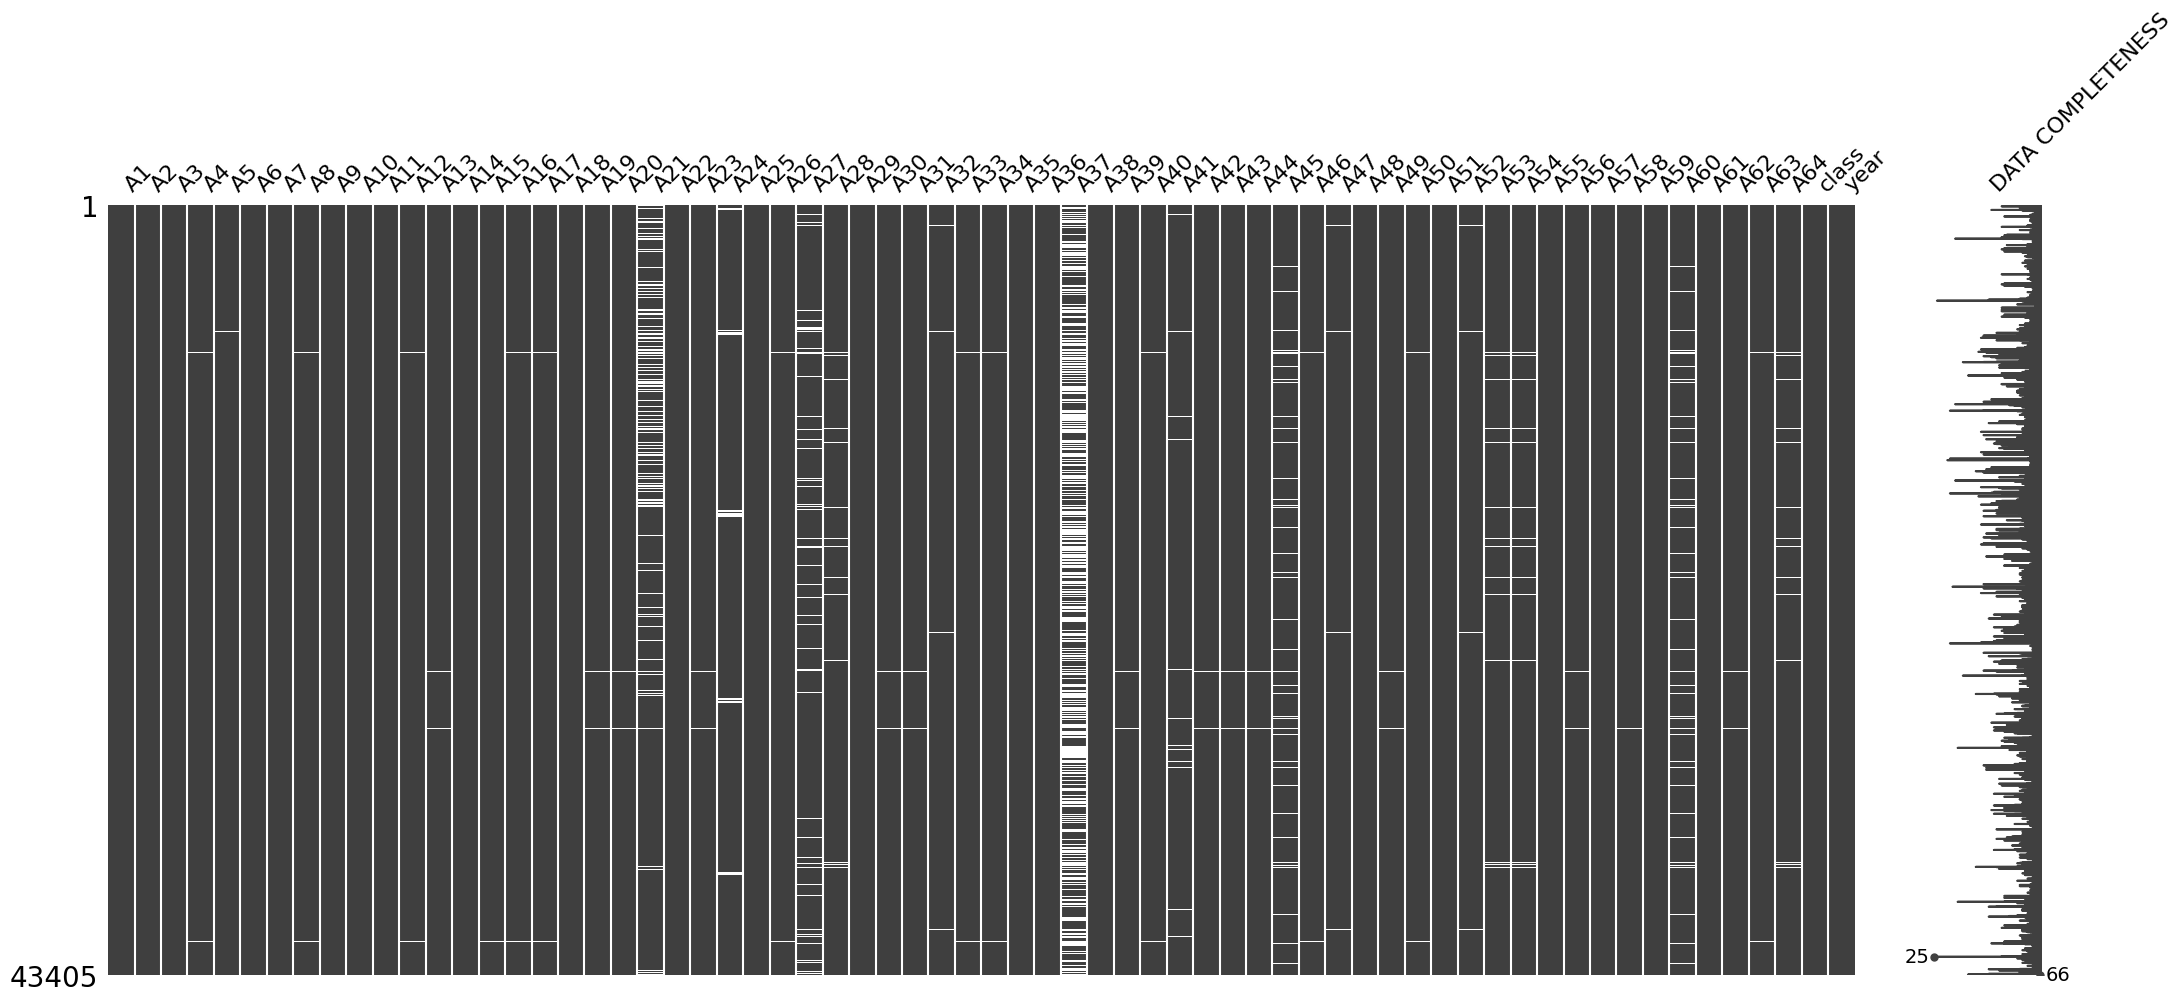

In [ ]:
msno.matrix(df,labels= True)
plt.show()

En  gran escala, no existe un patrón muy marcado entre los datos faltantes, pero notamos algunas columnas que tienen similitud con ``A45``.

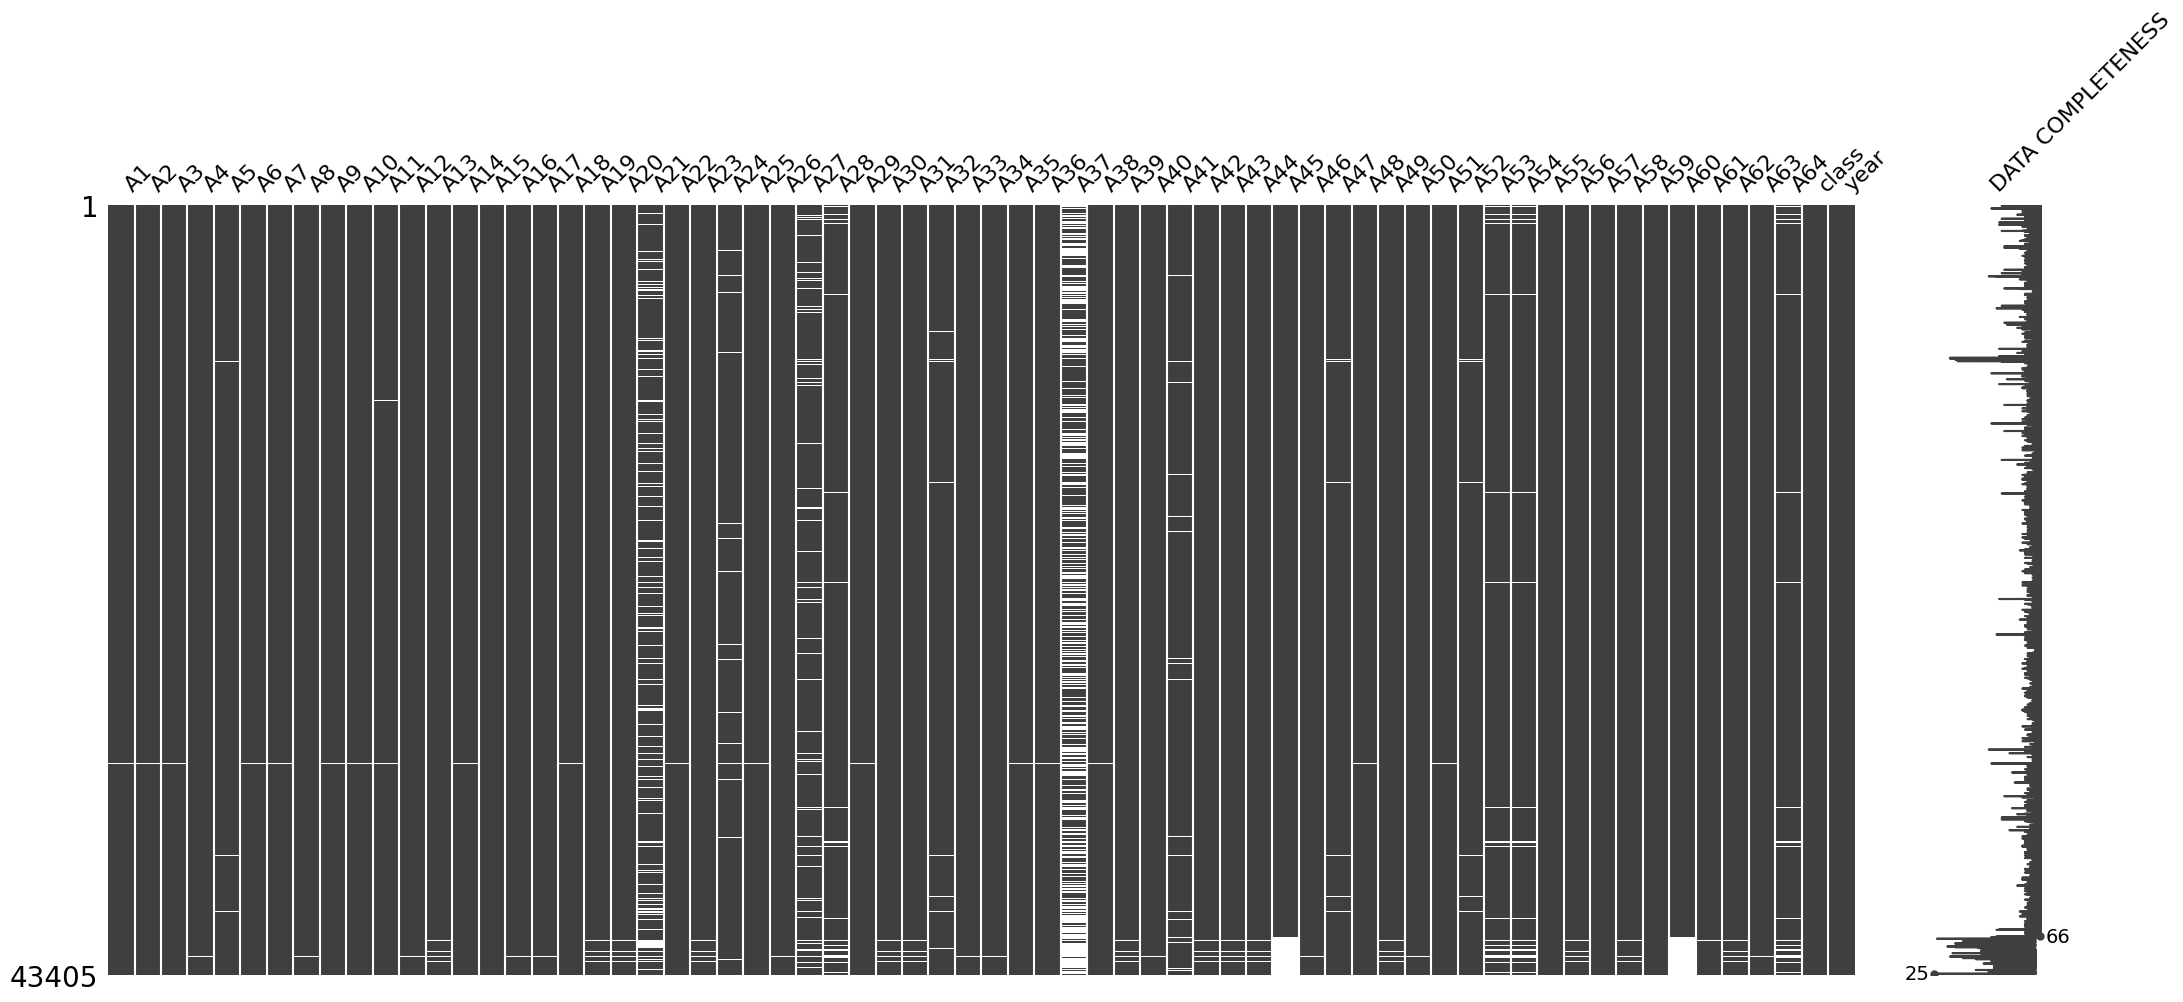

In [ ]:
msno.matrix(df.sort_values(by="A45"), labels= True)
plt.show()

Cabe mencionar que sí hay varios patrones aparte del anterior, pero, dado la baja cantidad de vacíos en estos, no son impactantes en los datos. Dado lo anterior, se decide eliminar las variables que, a lo menos, les falte el 5% de sus datos.

Así, el dataframe no posee vacíos considerables:

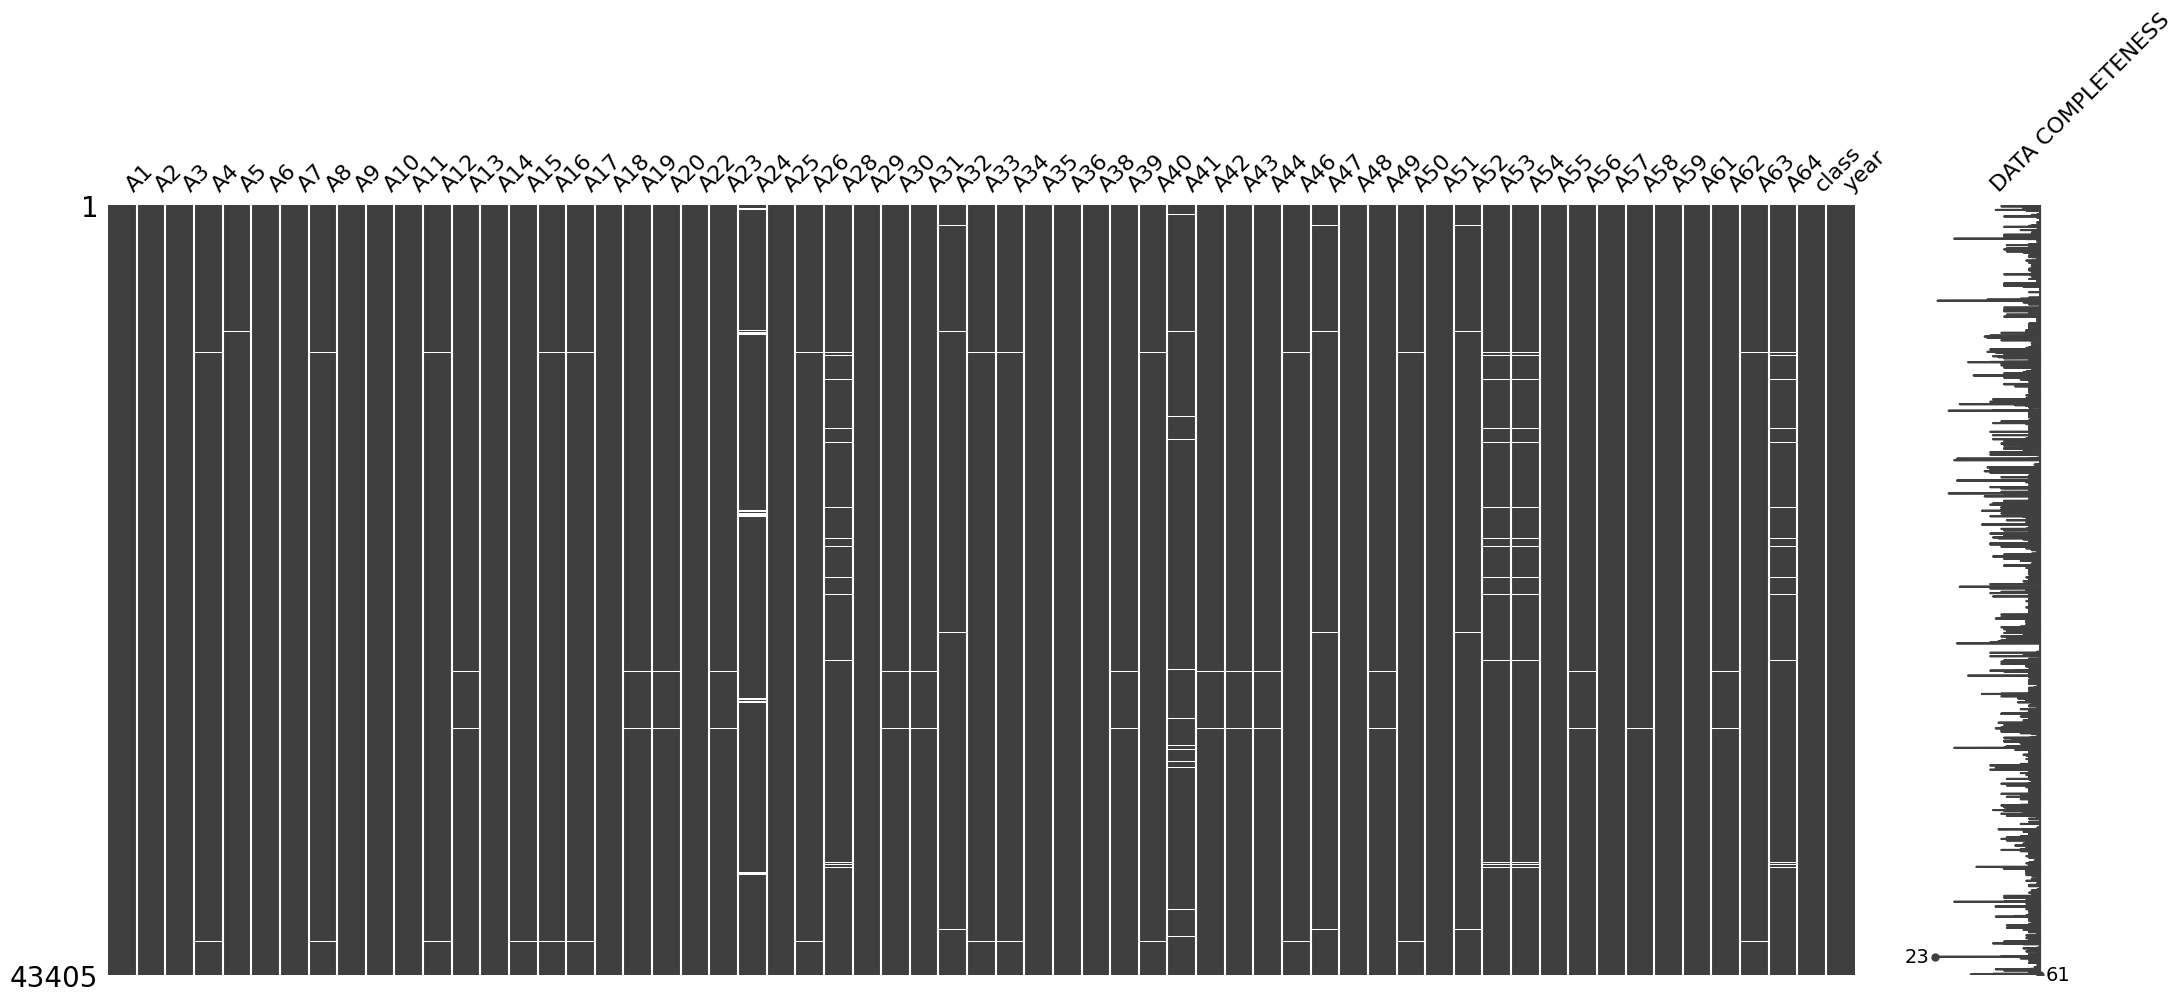

In [ ]:
df = df.drop(columns=["A21", "A27", "A37", "A45", "A60"])
msno.matrix(df,labels= True)
plt.show()

Después de este procedimiento es natural que surga la siguiente pregunta: ¿Qué hacemos con los vacíos restantes? La respuesta está ligada al tratamiento de outliers, donde estas 2 opciones destacaron para nosotros:
1. Dejar el Dataframe como está
2. Convertir los outliers en NaN y luego reemplazar los NaN por las medias de la columnas

Originalmente nos inclinamos por la segunda opción, pese al riesgo de sesgar los resultados. Sin embargo, luego del feedback recibido, decidimos ir más allá: Hacer las 2 opciones y comparar resultados. Por lo tanto, creamos una copia del dataframe:

In [ ]:
df_original = df.copy(deep=True) # Este es el que no trataermos

Ahora, para tratar los outliers utilizaremos el método [IQR](https://medium.com/@martacasdelg/cómo-identificar-y-tratar-outliers-con-python-bf7dd530fc3#:~:text=El%20IQR%20es%20una%20medida,los%20valores%20se%20consideran%20atípicos.) y el método [Zscore](https://www.soyfocus.com/z-score/) (con umbral = 3), los cuales no entraremos en detalles pero cuentan con enlaces que llevan a más información. Aquí funciones que automatizan esto:

In [ ]:
# Función para detectar y reemplazar outliers usando IQR
def reemplazar_outliers_iqr(df, columnas):
    df_reemplazo = df.copy()
    for col in columnas:
        Q1 = df_reemplazo[col].quantile(0.25)
        Q3 = df_reemplazo[col].quantile(0.75)
        IQR = Q3 - Q1
        # Definir los límites inferior y superior
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        # Reemplazar outliers por NaN
        df_reemplazo.loc[(df_reemplazo[col] < limite_inferior) | \
                         (df_reemplazo[col] > limite_superior), col] = np.nan
    return df_reemplazo

# Función para detectar y reemplazar outliers usando z-score
def reemplazar_outliers_zscore(df, columnas, umbral=3):
    df_reemplazo = df.copy()
    for col in columnas:
        # Calcular el z-score de cada valor en la columna
        z_scores = stats.zscore(df_reemplazo[col])
        # Reemplazar valores cuyo z-score absoluto
        # sea mayor que el umbral por NaN
        df_reemplazo.loc[np.abs(z_scores) > umbral, col] = np.nan
    return df_reemplazo

# Función combinada para detectar y reemplazar outliers usando ambos métodos
def reemplazar_outliers_combinado(df, columnas, umbral_zscore=3):
    # Primero aplicar eliminación de outliers usando IQR
    df_reemplazo_iqr = reemplazar_outliers_iqr(df, columnas)
    # Luego aplicar eliminación de outliers usando z-score
    df_reemplazo_combinado = reemplazar_outliers_zscore(df_reemplazo_iqr, columnas, umbral_zscore)
    return df_reemplazo_combinado

Ahora, aplicamos esto a nuestro dataframe teniendo cuidado en sólo aplicarlo en números y en las variables que no sean ``'class'`` o ``'year'``:

In [ ]:
# Seleccionar las columnas a evaluar (todas menos 'class' y 'year')
columnas_evaluar = df.select_dtypes(include=[np.number]).columns.tolist()
columnas_evaluar = [col for col in columnas_evaluar if col not in ['class', 'year']]

# Aplicar el filtro combinado a las columnas seleccionadas
df = reemplazar_outliers_combinado(df, columnas_evaluar)

Notemos que ahora contamos con aún más datos faltantes, así que los rellenamos con la media de la respectiva columna:

In [ ]:
df.fillna(df.mean(), inplace=True)
df_tratado = df.copy(deep=True)

# Análisis de Datos y Matriz de Características


En primera instancia, veamos nuestra variable objetivo, es decir, la cantidad de empresas que quiebran (quebrar viene representado por un 1):

In [ ]:
# Cantidad en bancarrota (es lo mismo para ambos dataframes)
df_original["class"].value_counts()

,count
class,
0,41314
1,2091


Ahora veamos cómo evolucion esto temporalmente:

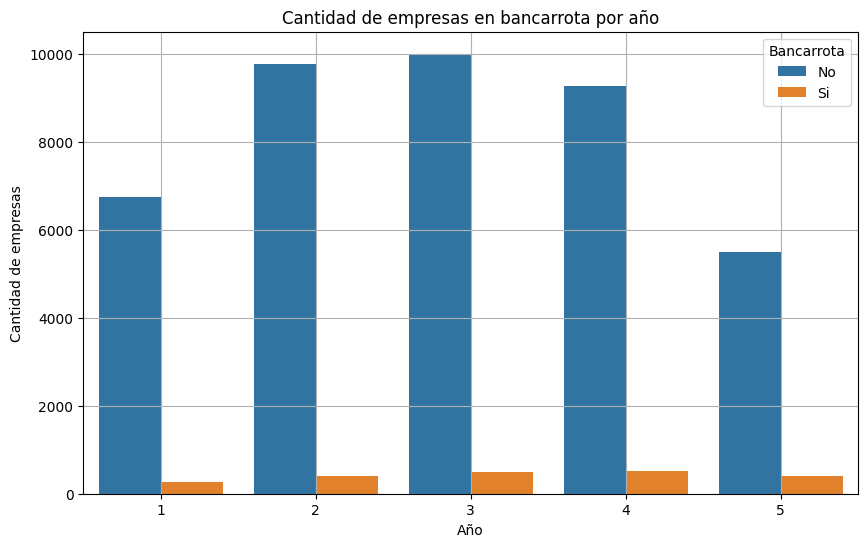

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='year', hue='class', data=df_original)
plt.title('Cantidad de empresas en bancarrota por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de empresas')
plt.legend(title='Bancarrota', labels=['No', 'Si'])
plt.grid(True)
plt.show()

Notemos que se observa un pequeño aumento a lo largo de los años. Para comprobar esta tendencia, veamos la tasa de bancarrota por año:

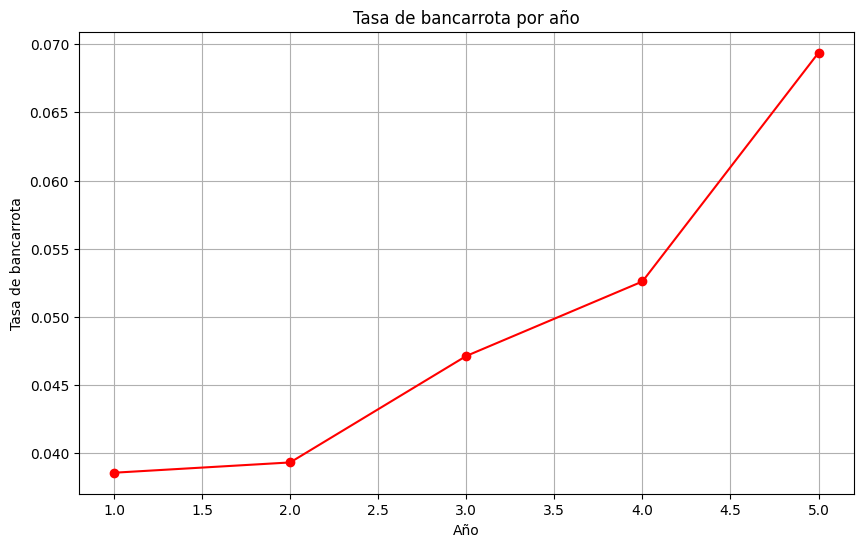

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(df_original.groupby('year')['class'].mean(), marker = "o", color = "r")
plt.title('Tasa de bancarrota por año')
plt.xlabel('Año')
plt.ylabel('Tasa de bancarrota')
plt.grid(True)
plt.show()

Ahora veamos la Matriz de Carácteristicas:

In [ ]:
df_original.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A61,A62,A63,A64,class,year
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,5.1372,82.658,4.4158,7.4277,0,1
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,3.2732,107.350,3.4000,60.9870,0,1
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,3.9510,134.270,2.7185,5.2078,0,1
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,3.6147,86.435,4.2228,5.5497,0,1
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,4.3158,127.210,2.8692,7.8980,0,1


In [ ]:
df_original.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,A56,A57,A58,A59,A61,A62,A63,A64,class,year
count,43397.000000,43397.000000,43397.000000,43271.000000,4.331600e+04,43397.000000,43397.000000,43311.000000,43396.000000,43397.000000,...,4.327800e+04,43398.000000,4.332100e+04,43398.000000,43303.000000,4.327800e+04,43271.000000,42593.000000,43405.000000,43405.000000
mean,0.035160,0.590212,0.114431,6.314702,-3.853466e+02,-0.056107,0.093478,12.640779,2.652166,0.626868,...,-2.621959e+01,-0.010510,3.002644e+01,1.333288,17.033202,1.502328e+03,9.343074,72.788592,0.048174,2.939753
std,2.994109,5.842748,5.439429,295.434425,6.124303e+04,7.201326,5.713075,505.894281,62.932732,14.670597,...,5.327862e+03,13.674072,5.334454e+03,122.104445,553.049406,1.392667e+05,124.177354,2369.339482,0.214137,1.283975
min,-463.890000,-430.870000,-479.960000,-0.403110,-1.190300e+07,-508.410000,-517.480000,-141.410000,-3.496000,-479.910000,...,-1.108300e+06,-1667.300000,-1.986900e+02,-327.970000,-12.656000,-2.336500e+06,-1.543200,-10677.000000,0.000000,1.000000
25%,0.003429,0.268980,0.021521,1.049500,-4.908000e+01,0.000000,0.005776,0.430275,1.018500,0.295470,...,9.348500e-03,0.014649,8.753200e-01,0.000000,4.510150,4.214400e+01,3.097650,2.176800,0.000000,2.000000
50%,0.049660,0.471900,0.196610,1.569800,-1.034500e+00,0.000000,0.059634,1.070400,1.195350,0.505970,...,5.294300e-02,0.119670,9.509600e-01,0.006366,6.636300,7.132600e+01,5.087600,4.282500,0.000000,3.000000
75%,0.129580,0.688320,0.403390,2.787450,5.063425e+01,0.089446,0.150880,2.615700,2.062500,0.709100,...,1.290975e-01,0.284605,9.926400e-01,0.236052,10.394500,1.172200e+02,8.598850,9.776200,0.000000,4.000000
max,94.280000,480.960000,28.336000,53433.000000,1.250100e+06,543.250000,649.230000,53432.000000,9742.300000,1099.500000,...,2.931500e+02,552.640000,1.108300e+06,23853.000000,108000.000000,2.501600e+07,23454.000000,294770.000000,1.000000,5.000000


De momento, queda pendiente reemplazar los nombres de las columnas por aquellos más descriptivos guardados en ``data_dict``. Esto se hará más adelante para simplificar el desarrollo.

Ahora, tomaremos una muestra de 5 variables (columnas) para hacer un análisis un poco más profundo. En el [modelo de un usuario de Kaggle](https://www.kaggle.com/code/sasakitetsuya/bankruptcy-rate-for-each-year) se determinó que las siguientes 5 variables son las que tienen más peso:


1. **A48: “EBITDA / Total assets”**

2. **A35: "profit on sales / total assets”**

3. **A36: “total sales / total assets”**

4. **A46: “(current assets - inventory) / short-term liabilities”**

5. **A38: “constant capital / total**


Por lo que estimamos pertinente escoger estas 5 variables como parte de la "muestra" para analizar. Primero, una breve descripción de estas:



*  **A48 “EBITDA / Total assets”:** El EBITDA (Earnings Before Interest, Taxes, Depreciation, and Amortization) es una métrica comúnmente utilizada porque ofrece una visión más clara del rendimiento operativo puro. Indica que tan bien opera la empresa para generar dinero, donde un número alto da un indicio positivo.

*   **A35 "profit on sales / total assets”:** Mide la rentabilidad de los activos de la empresa en función de las ganancias obtenidas por las ventas. Un valor bajo indica que la empresa no está obteniendo suficientes ganancias en relación con sus activos, lo que podría sugerir ineficiencias operativas o problemas para convertir sus activos en ventas y ganancias.



*   **A36 “total sales / total assets”:** Mide la eficiencia con la que una empresa utiliza sus activos para generar ingresos a través de las ventas. Un valor alto de este ratio indica que la empresa está utilizando eficazmente sus activos para generar ingresos. Es decir, la empresa está aprovechando bien sus recursos para obtener ventas.

*  **A46 “(current assets - inventory) / short-term liabilities”:** Mide la capacidad de una empresa para cubrir sus obligaciones a corto plazo usando solo sus activos corrientes netos de inventario. Un bajo valor puede ser un signo de que la empresa no puede cubrir sus deudas inmediatas sin vender inventarios o adquirir financiamiento adicional.


*   **A38 “constant capital / total assets”:** Mide la proporción de los activos totales de una empresa que está financiada por capital constante. Un valor alto puede señalar rigidez financiera y dificultades para obtener liquidez, lo que puede ser un factor de riesgo en situaciones de estrés financiero.

Ahora, el análisis:






In [ ]:
variables_interes = ["A48", "A35", "A36", "A46", "A38", "class", "year"]
df_muestra_original = df_original[variables_interes]
df_muestra_tratado = df_tratado[variables_interes]

for col, name in data_dict.items():
  df_muestra_original.rename(columns={col: name}, inplace=True)
  df_muestra_tratado.rename(columns={col: name}, inplace=True)

In [ ]:
df_muestra_original.head()

,EBITDA (profit on operating activities - depreciation) / total assets,profit on sales / total assets,total sales / total assets,(current assets - inventory) / short-term liabilities,constant capital / total assets,class,year
0,0.185300,0.21402,1.7410,1.52250,0.50591,0,1
1,0.237270,0.20616,1.6996,1.12520,0.49788,0,1
2,0.291810,0.31565,1.3090,1.01010,0.51537,0,1
3,0.085874,0.11550,1.3562,1.56960,0.57353,0,1
4,0.188110,0.19832,1.6278,0.95787,0.43489,0,1


In [ ]:
df_muestra_original.describe()

,EBITDA (profit on operating activities - depreciation) / total assets,profit on sales / total assets,total sales / total assets,(current assets - inventory) / short-term liabilities,constant capital / total assets,class,year
count,43396.000000,43397.000000,43397.000000,43270.000000,43397.000000,43405.000000,43405.000000
mean,0.028584,0.111908,2.911241,5.428857,0.724357,0.048174,2.939753
std,5.097322,4.783398,62.984347,295.356200,14.749270,0.214137,1.283975
min,-542.560000,-431.590000,-0.000857,-101.260000,-479.910000,0.000000,1.000000
25%,-0.038183,0.006038,1.101100,0.607455,0.419830,0.000000,2.000000
50%,0.018430,0.060655,1.643400,1.026650,0.612150,0.000000,3.000000
75%,0.107332,0.150070,2.420900,1.910775,0.771830,0.000000,4.000000
max,623.850000,626.920000,9742.300000,53433.000000,1099.500000,1.000000,5.000000


Dado a la gran dispersión de los datos, no es posible generar un histograma. Cabe mencionar que esta dispersión no es un problema y, de hecho, es natural dado a las estadísticas que se estudian (estadísticas que suelen variar y alcanzar valores muy distintos).

Lo que sí se puede crear son diagramas de cajas:

In [ ]:
for col in df_muestra_original.columns:
  if col == "year" and col == "class":
    df_muestra_original.boxplot(column=[col])
    plt.title(f'Boxplot de {col}')
    plt.grid(True)
    plt.ylabel("Valores")
    plt.show()

Veamos el promedio de cada dato por cada año:

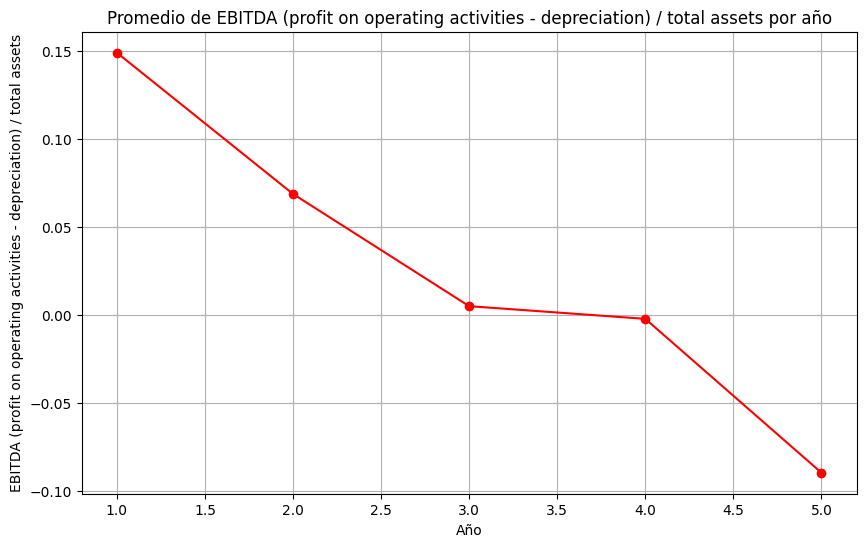

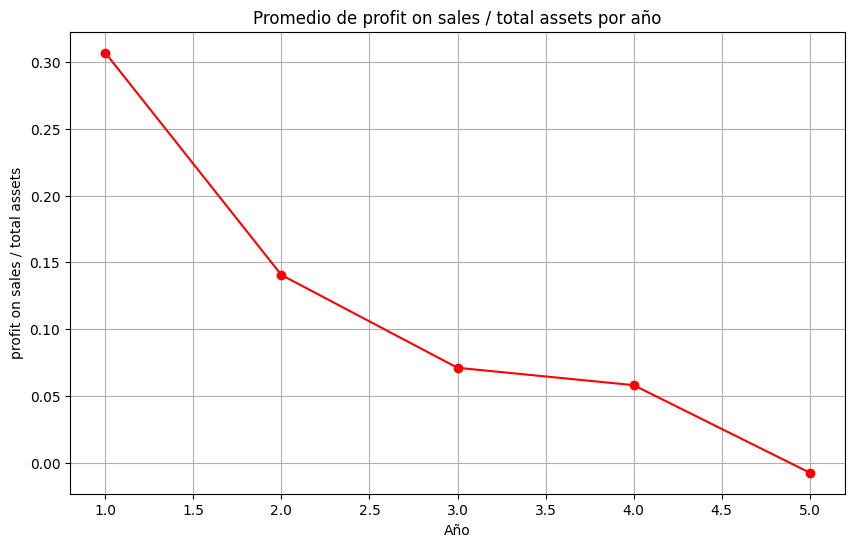

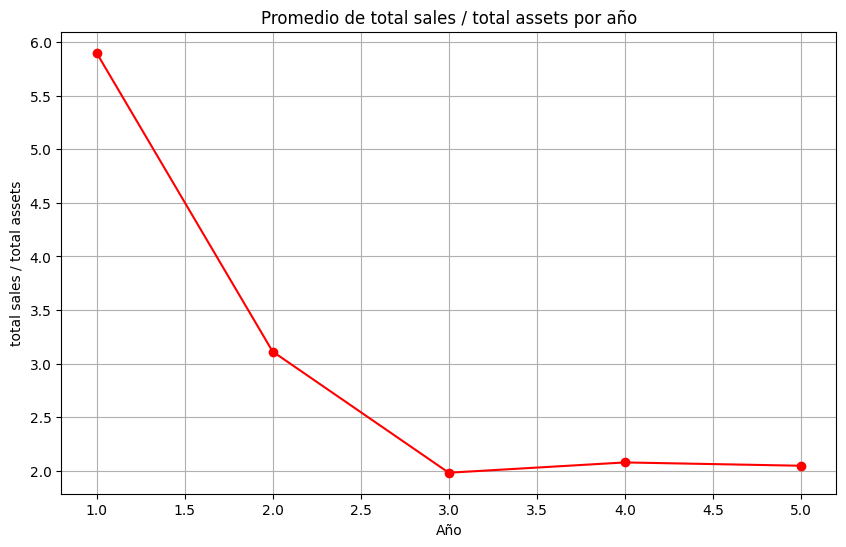

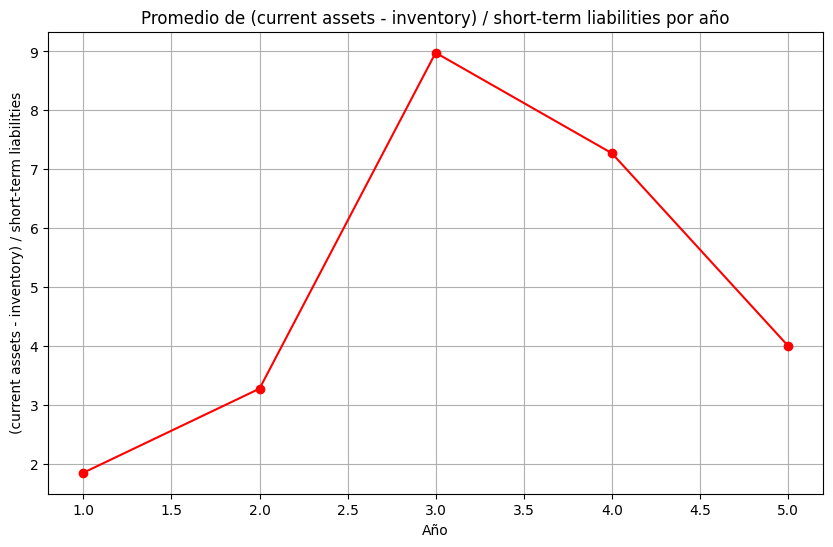

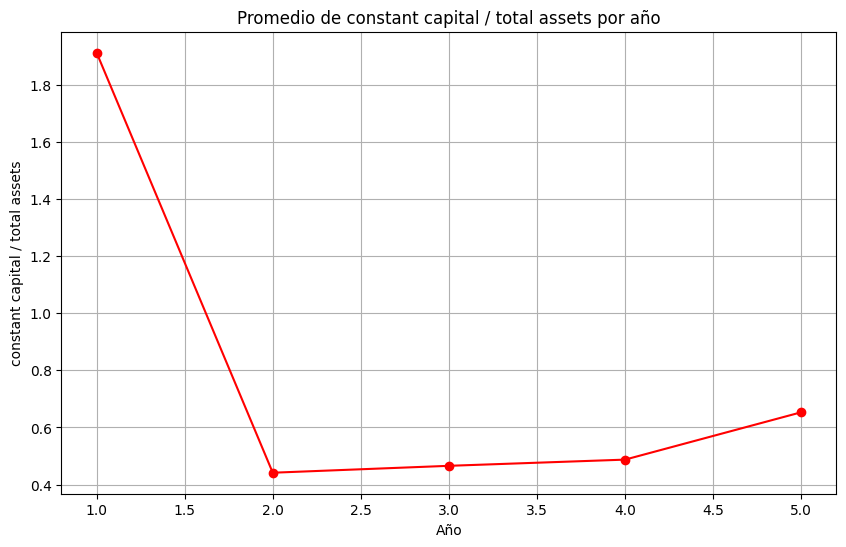

In [ ]:
for col in df_muestra_original.columns:
  if col != "year" and col != "class":
    plt.figure(figsize=(10, 6))
    promedio_por_año = df_muestra_original.groupby('year')[col].mean()
    plt.plot(promedio_por_año.index, promedio_por_año.values, marker="o", color="r")
    plt.title(f'Promedio de {col} por año')
    plt.xlabel('Año')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

## Para el dataframe original:

Intentemos comparar los valores de estas variables cuando se declara la bancarrota vs cuando no:

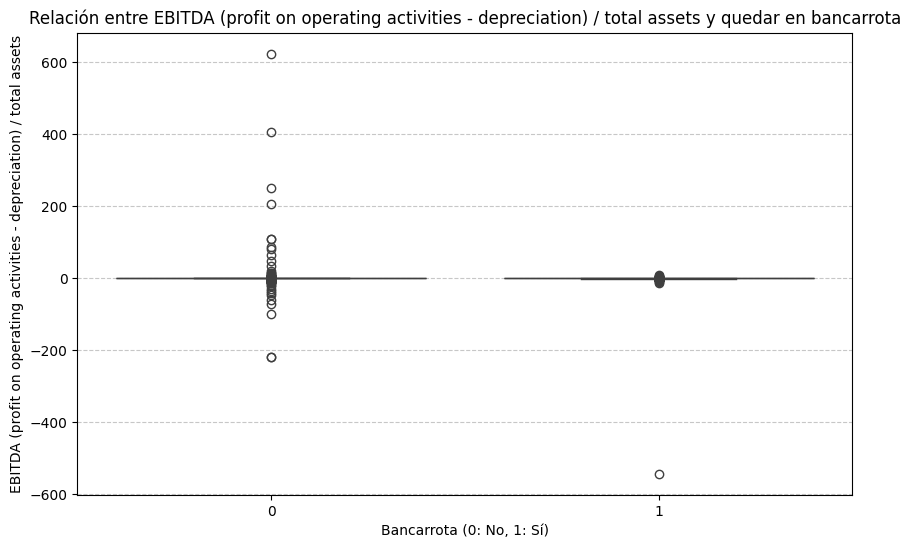

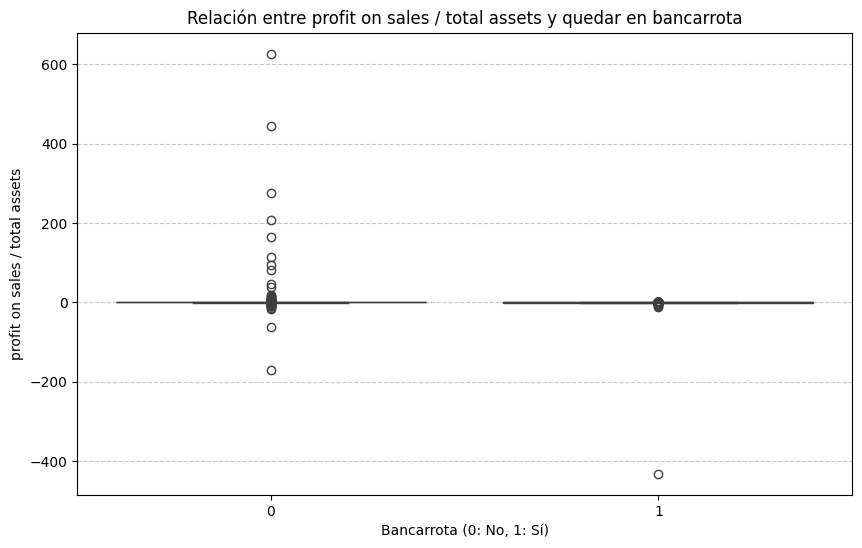

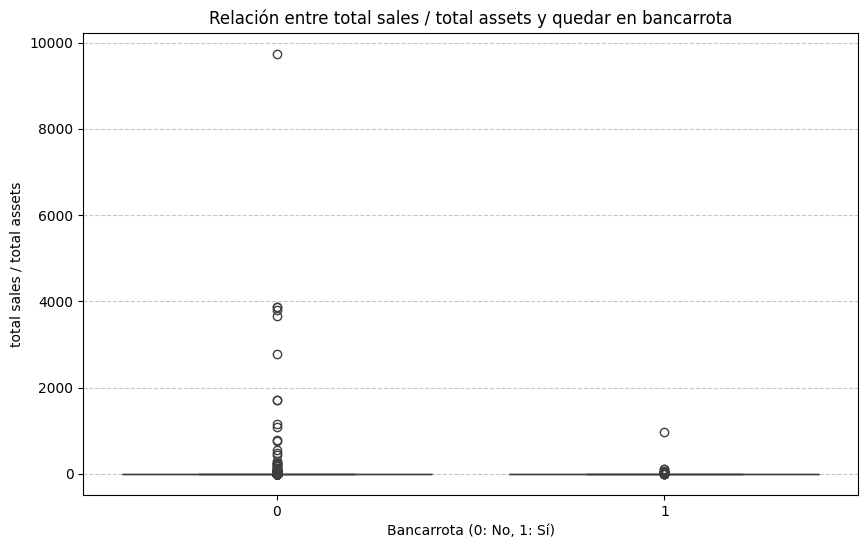

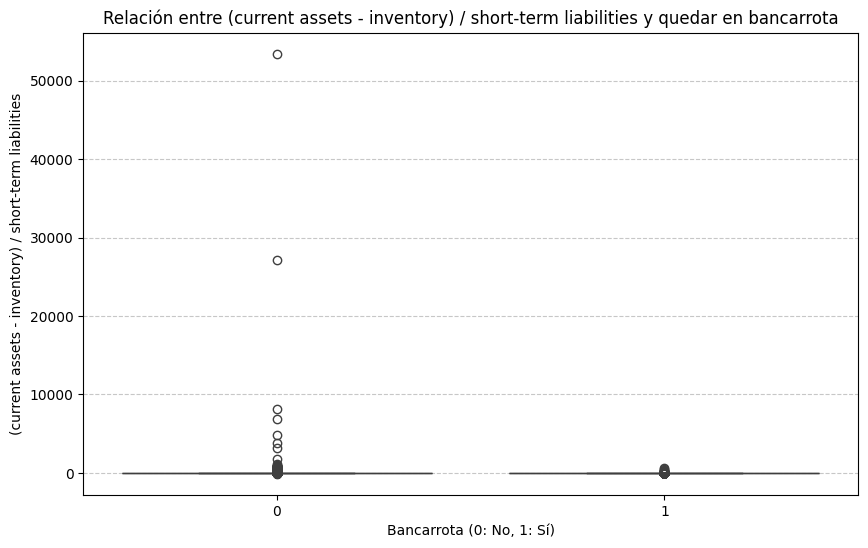

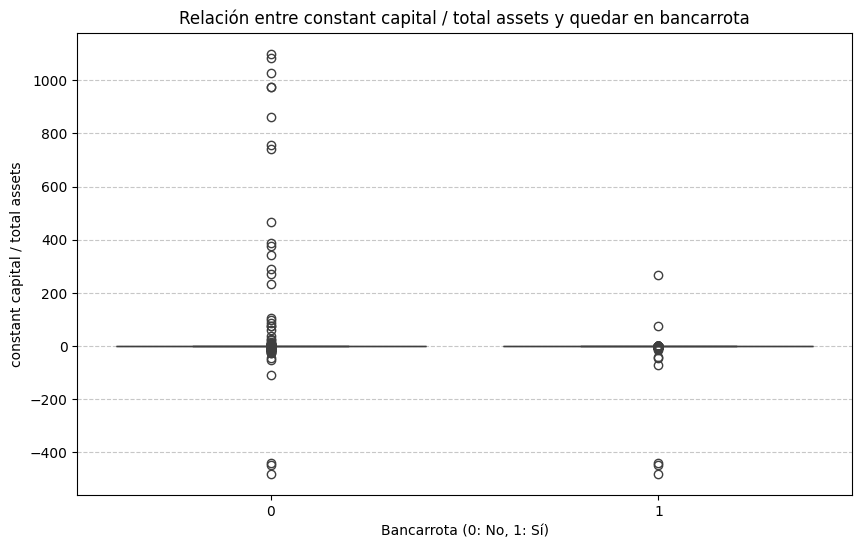

In [ ]:
for col in df_muestra_original.columns:
    if col != "year" and col != "class":
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_muestra_original, x='class', y=col)
        plt.title(f'Relación entre {col} y quedar en bancarrota')
        plt.xlabel('Bancarrota (0: No, 1: Sí)')
        plt.ylabel(col)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


Finalmente, veamos un heatmap:

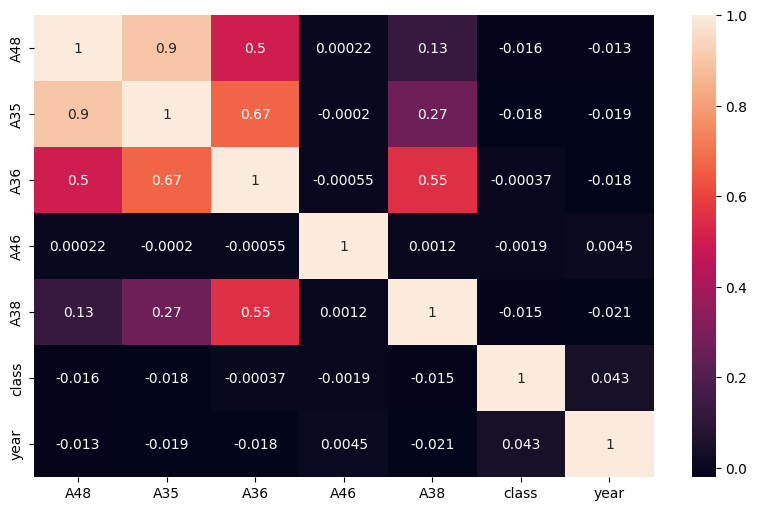

In [ ]:
# Se cambian los nombres para la legibilidad
heatmap_labels = [next((key for key, value in data_dict.items() if value == col and value), col) for col in df_muestra_original.columns]
plt.figure(figsize=(10, 6))
sns.heatmap(df_muestra_original.corr(), annot=True, xticklabels=heatmap_labels, yticklabels=heatmap_labels)
plt.show()

## Para el dataframe tratado:

Es importante notar que el siguiente análisis no es representativo de los datos reales debido a la naturaleza del tratamiento. Sin embargo, puede ser útil para tener una noción de cómo se comportan los datos "en torno a la media".

In [ ]:
df_muestra_tratado.head()

,EBITDA (profit on operating activities - depreciation) / total assets,profit on sales / total assets,total sales / total assets,(current assets - inventory) / short-term liabilities,constant capital / total assets,class,year
0,0.185300,0.21402,1.7410,1.52250,0.50591,0,1
1,0.237270,0.20616,1.6996,1.12520,0.49788,0,1
2,0.291810,0.31565,1.3090,1.01010,0.51537,0,1
3,0.085874,0.11550,1.3562,1.56960,0.57353,0,1
4,0.188110,0.19832,1.6278,0.95787,0.43489,0,1


In [ ]:
df_muestra_tratado.describe()

,EBITDA (profit on operating activities - depreciation) / total assets,profit on sales / total assets,total sales / total assets,(current assets - inventory) / short-term liabilities,constant capital / total assets,class,year
count,43405.000000,43405.000000,43405.000000,43405.000000,43405.000000,43405.000000,43405.000000
mean,0.032158,0.074382,1.724894,1.145996,0.593060,0.048174,2.939753
std,0.101888,0.100094,0.876892,0.764350,0.230582,0.214137,1.283975
min,-0.256430,-0.209990,-0.000857,-0.342860,-0.107990,0.000000,1.000000
25%,-0.021073,0.012585,1.101100,0.608900,0.445720,0.000000,2.000000
50%,0.032158,0.071518,1.643400,1.030300,0.611370,0.000000,3.000000
75%,0.082972,0.126320,2.210000,1.408400,0.771090,0.000000,4.000000
max,0.325580,0.366100,4.400600,3.863800,1.170100,1.000000,5.000000


Ahora, como los datos no están tan dispersos, podemos ver un histograma:



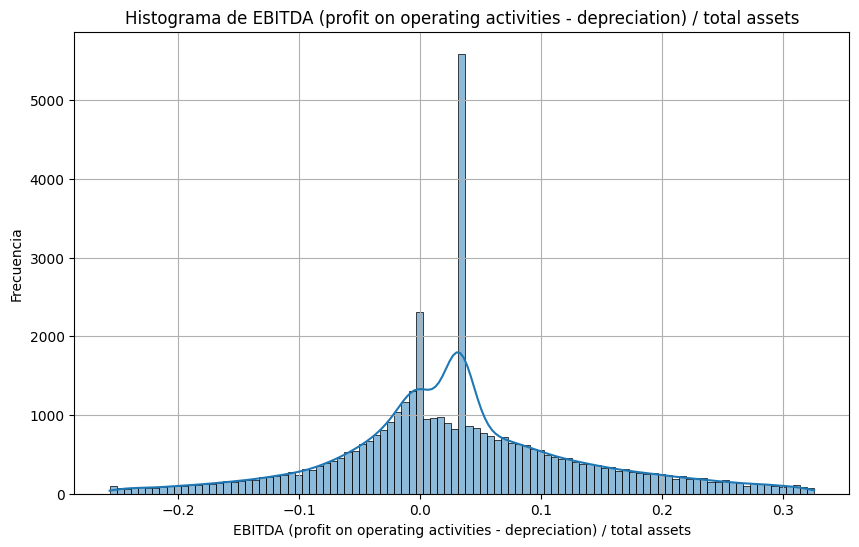

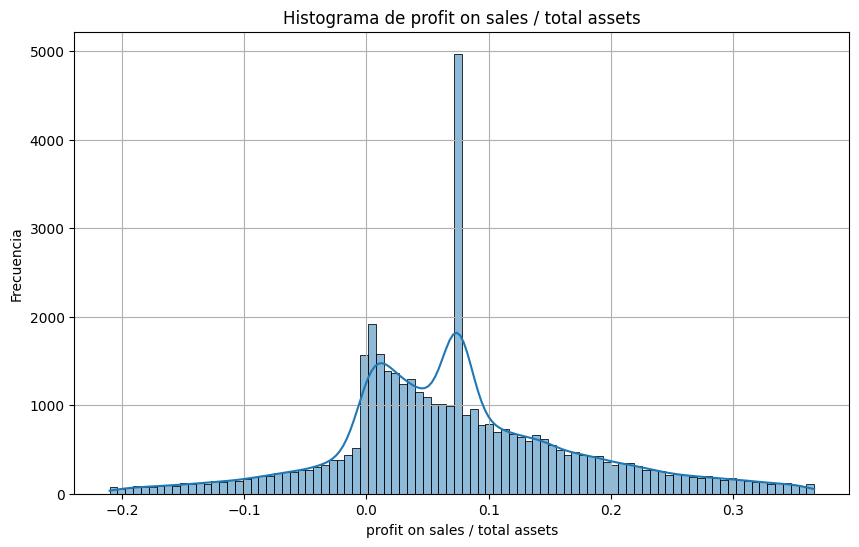

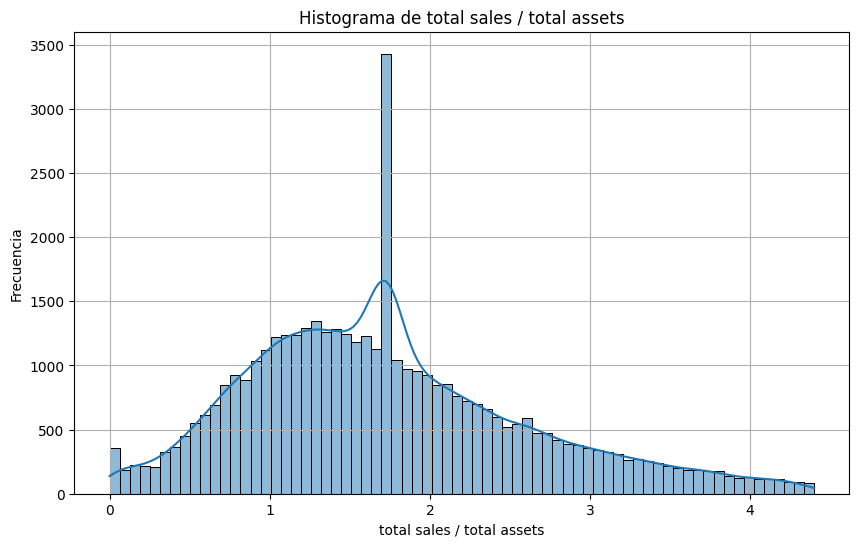

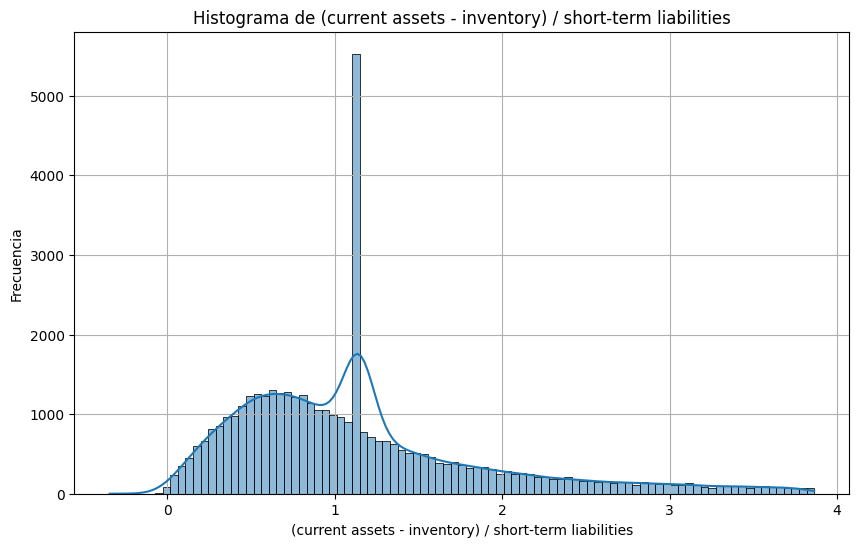

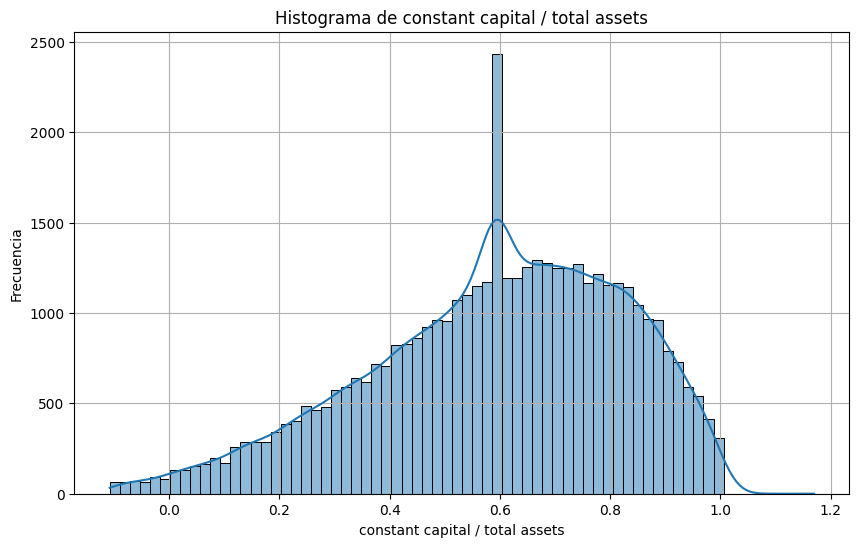

In [ ]:
for col in df_muestra_tratado.columns:
  if col != "year" and col != "class":
    plt.figure(figsize=(10, 6))
    sns.histplot(df_muestra_tratado[col], kde=True)
    plt.title(f'Histograma de {col}')
    plt.grid(True)
    plt.ylabel('Frecuencia')
    plt.xlabel(col)
    plt.show()

Veamos los diagramas de caja:

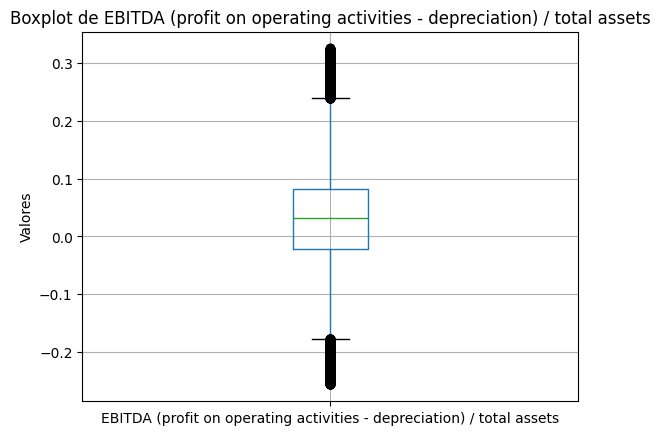

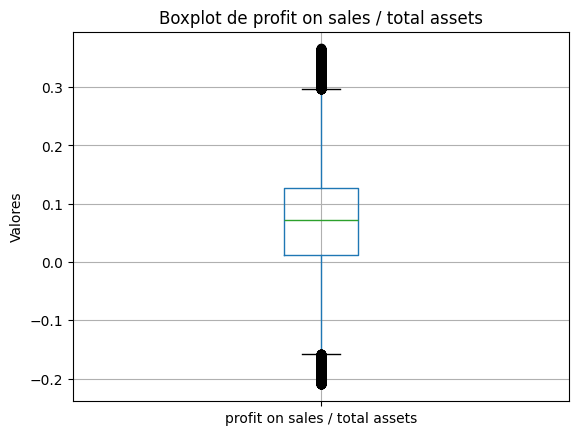

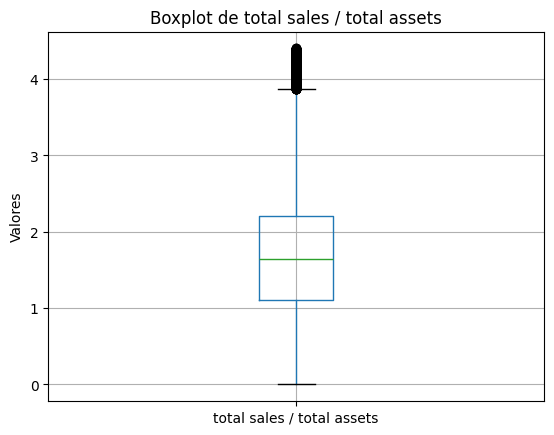

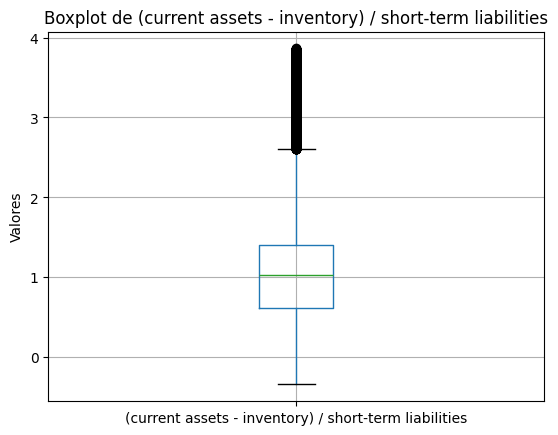

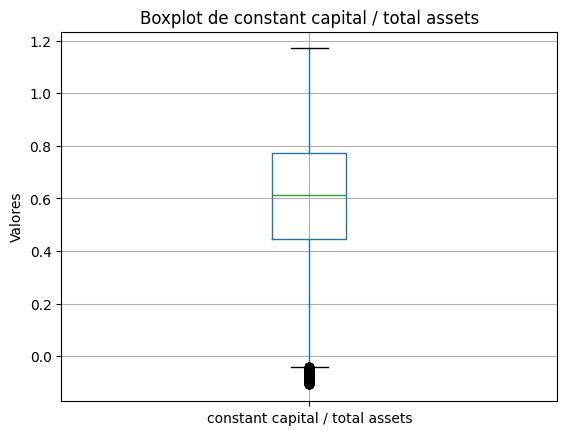

In [ ]:
for col in df_muestra_tratado.columns:
  if col != "year" and col != "class":
    df_muestra_tratado.boxplot(column=[col])
    plt.title(f'Boxplot de {col}')
    plt.grid(True)
    plt.ylabel("Valores")
    plt.show()

La media a través de los años:

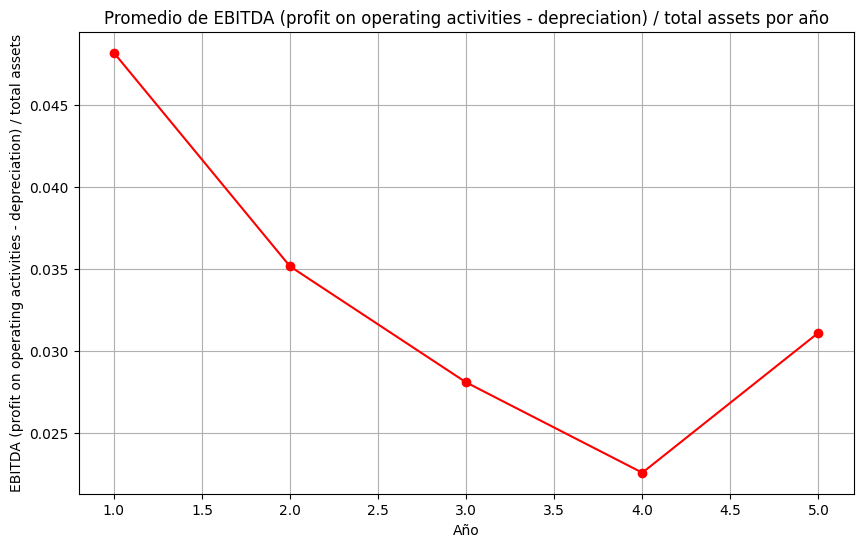

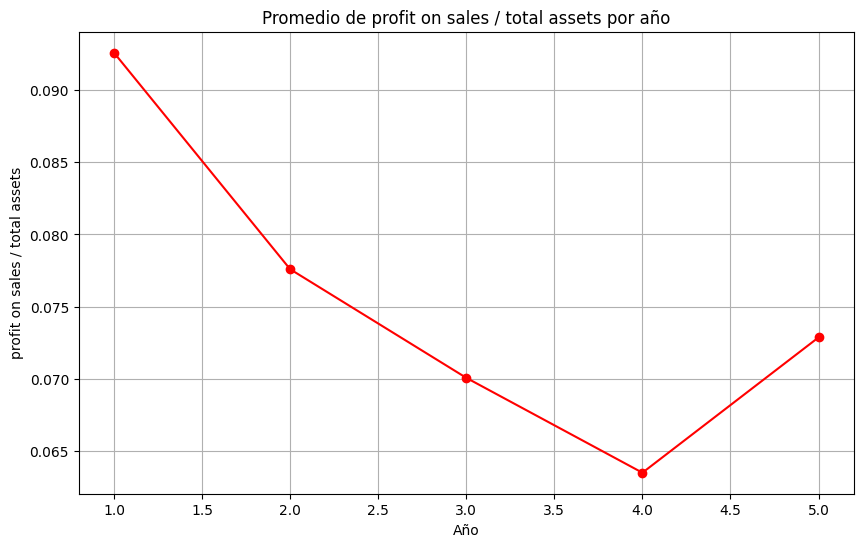

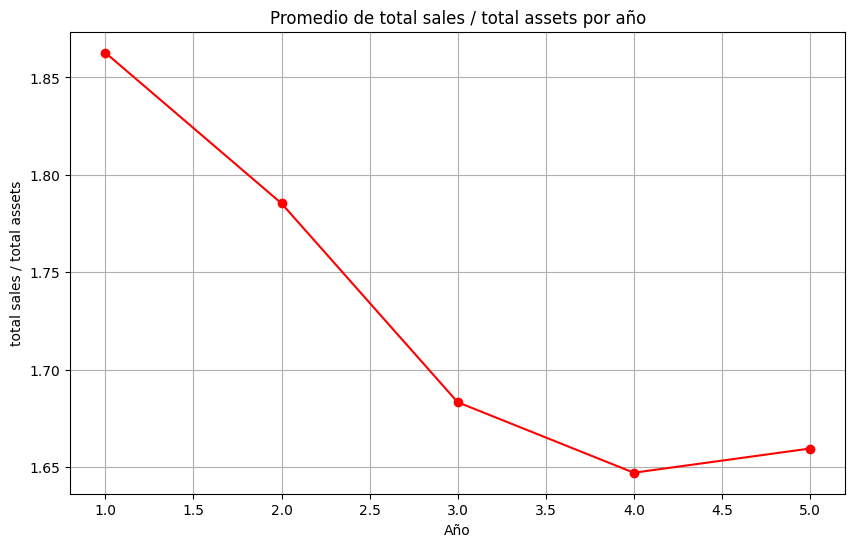

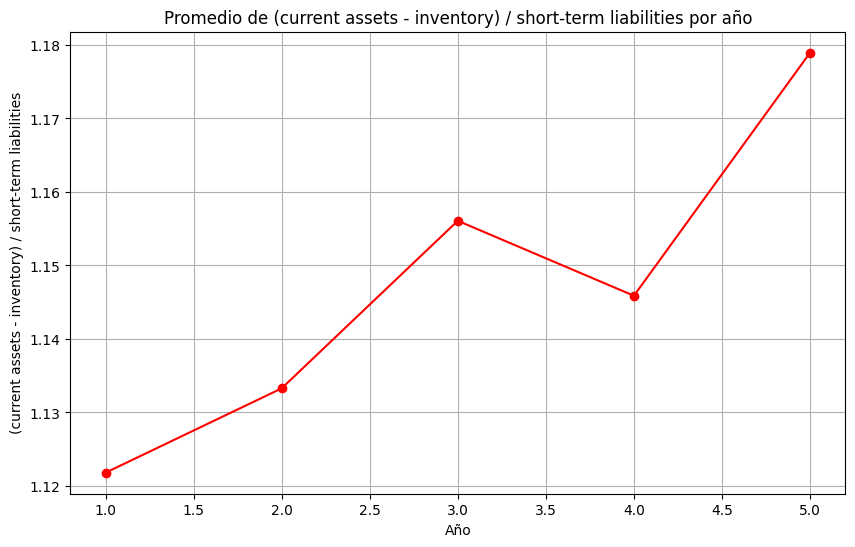

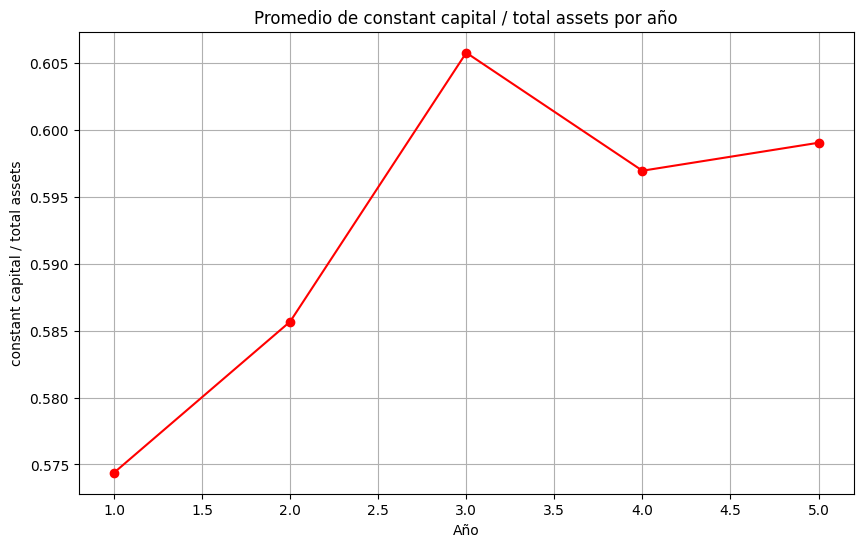

In [ ]:
for col in df_muestra_tratado.columns:
  if col != "year" and col != "class":
    plt.figure(figsize=(10, 6))
    promedio_por_año = df_muestra_tratado.groupby('year')[col].mean()
    plt.plot(promedio_por_año.index, promedio_por_año.values, marker="o", color="r")
    plt.title(f'Promedio de {col} por año')
    plt.xlabel('Año')
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

Comparación de los datos cuando hay bancarrota vs cuando no:

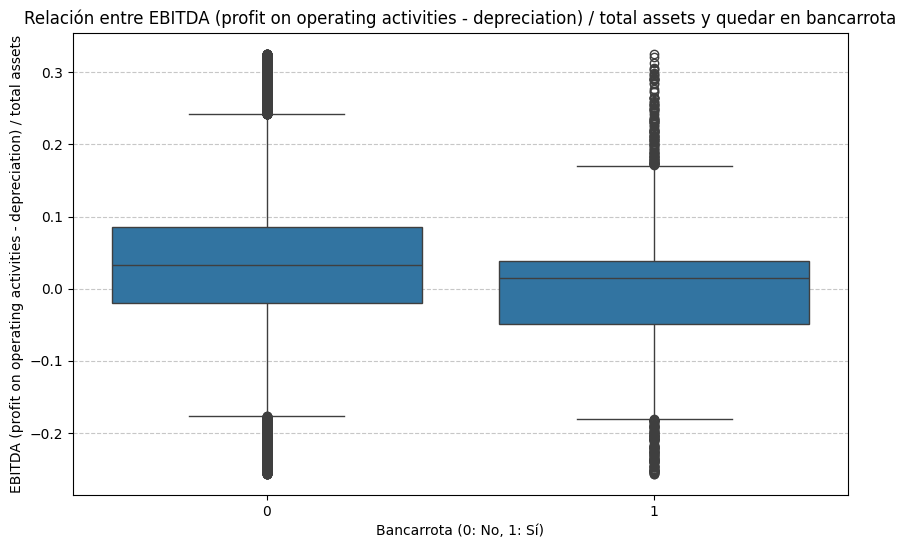

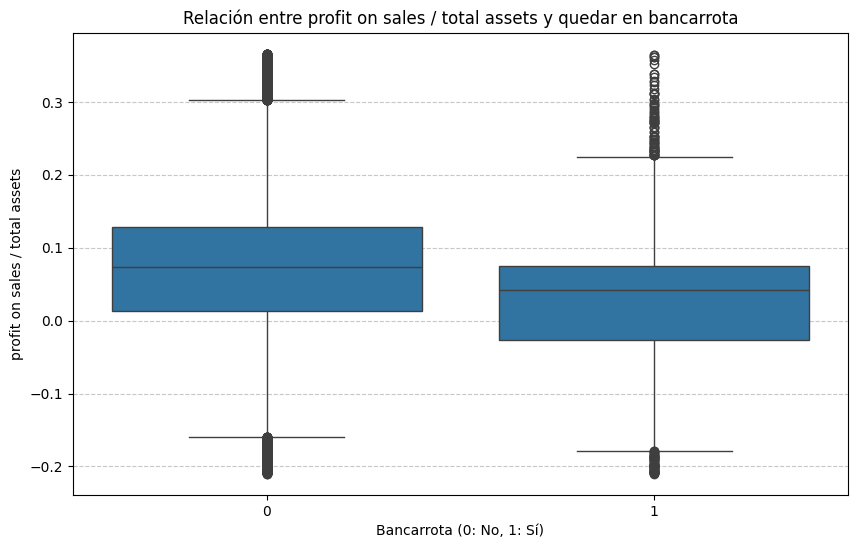

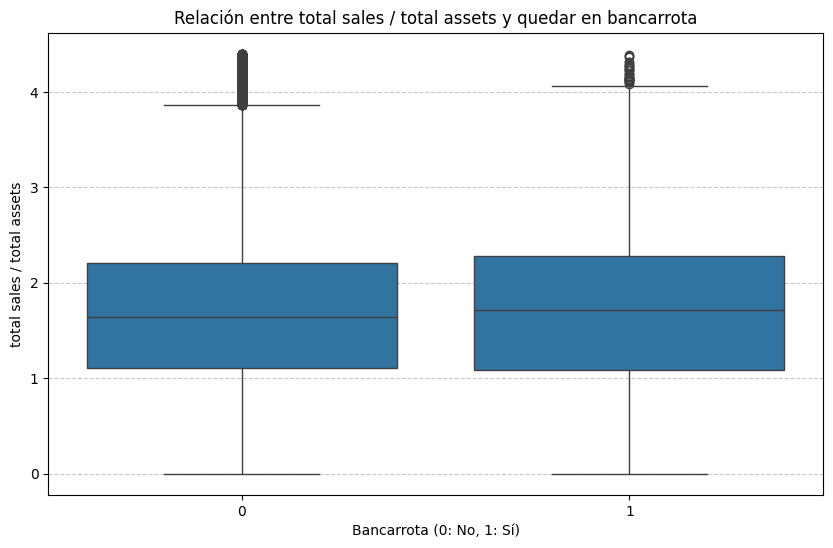

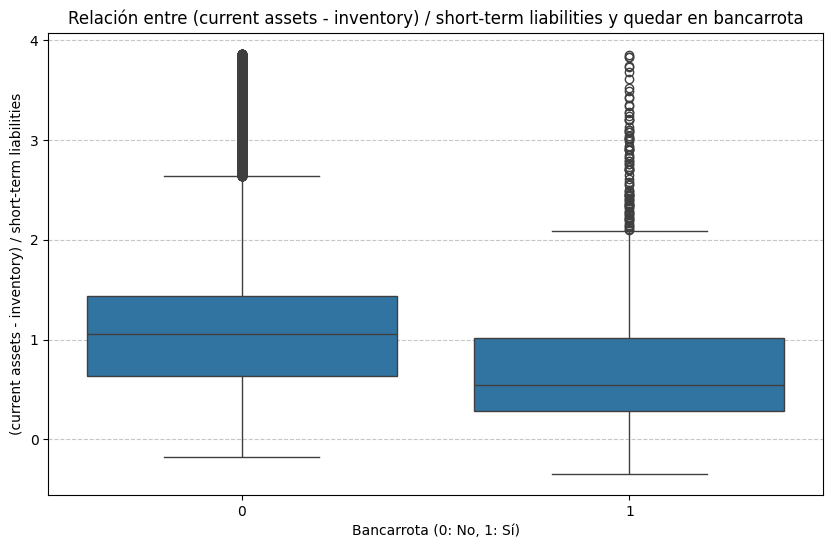

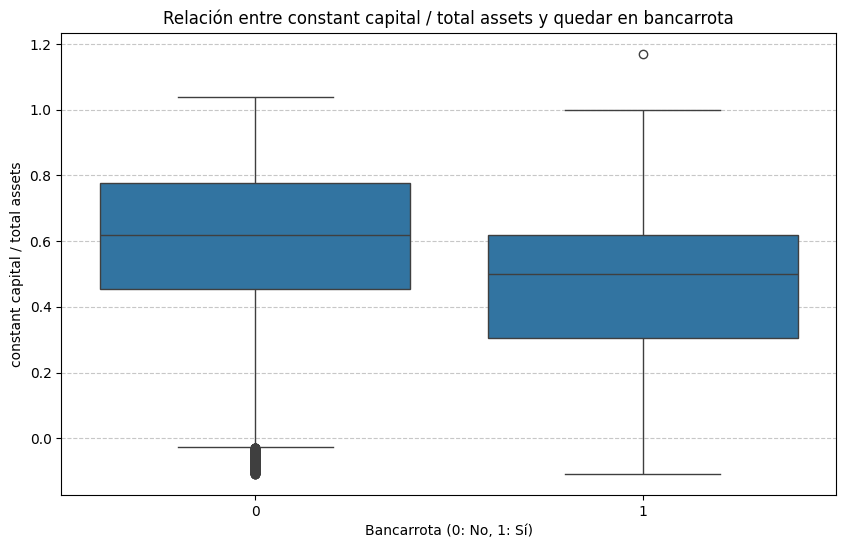

In [ ]:
for col in df_muestra_tratado.columns:
    if col != "year" and col != "class":
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df_muestra_tratado, x='class', y=col)
        plt.title(f'Relación entre {col} y quedar en bancarrota')
        plt.xlabel('Bancarrota (0: No, 1: Sí)')
        plt.ylabel(col)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()


Finalmente, el heatmap:

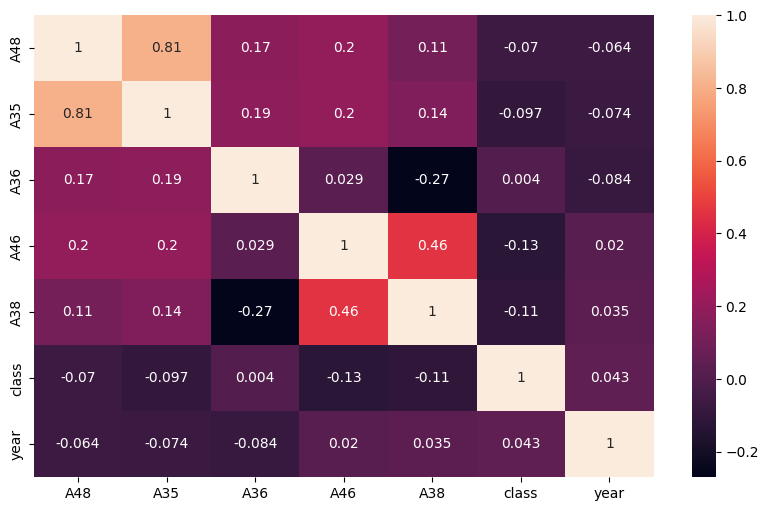

In [ ]:
# Se cambian los nombres para la legibilidad
heatmap_labels = [next((key for key, value in data_dict.items() if value == col and value), col) for col in df_muestra_tratado.columns]
plt.figure(figsize=(10, 6))
sns.heatmap(df_muestra_tratado.corr(), annot=True, xticklabels=heatmap_labels, yticklabels=heatmap_labels)
plt.show()

# Modelos y Resultados

## Random Forest

Este [modelo](https://anderfernandez.com/blog/guia-completa-random-forest/) es particularmente útil para finanzas debido a la gran cantidad de datos y la alta precisión a pesar de tener un conjunto de datos muy variable. A continuación la implementación:

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

def procesar_RF(dataframe, target_column='class', standar=False):
    """
    Entrena y evalua el modelo Random Forest en el dataframe ingresado

    Parametros:
        dataframe (pd.DataFrame)
        target_column (str)

    Retorna:
        dict
    """
    # Definimos X e Y
    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column]


    # Separamos los datos en entrenamiento y validacion
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

    # Estandarizamos los datos
    if standar:
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)
      X_val = scaler.transform(X_val)

    # Inicializando el modelo
    rf = RandomForestClassifier(random_state=42)

    # Ajustando el modelo
    rf.fit(X_train, y_train)

    # Predección en el conjunto de validación
    y_pred = rf.predict(X_val)

    # Matriz de confusión
    cm = confusion_matrix(y_val, y_pred)
    vn, fp, fn, vp = cm.ravel()

    # Calcular indicadores
    metrics = {
        "Correctitud": (vp + vn) / (vp + vn + fp + fn),
        "Sensibilidad (recall)": vp / (vp + fn),
        "Especificidad": vn / (vn + fp),
        "Precisión": vp / (vp + fp),
        "F1-Score": 2 * (vp / (vp + fp)) * (vp / (vp + fn)) / ((vp / (vp + fp)) + (vp / (vp + fn)))
    }

    # Importancia de las variables (Importancia de Gini)
    feature_importances = rf.feature_importances_
    return {
        "metrics": metrics,
        "confusion_matrix": cm,
        "feature_importances": feature_importances,
        "classification_report": classification_report(y_val, y_pred),
    }

### Datos originales

Primero hagamoslo sin estandarizar los datos:

In [ ]:
resultados_original = procesar_RF(df_original)

print("Métricas:", resultados_original["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_original["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_original["classification_report"], "\n")


importancia = pd.DataFrame({
    'Variable': df_original.drop(columns=['class']).columns,
    'Importancia': resultados_original["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9518982676004423, 'Sensibilidad (recall)': 0.10720887245841035, 'Especificidad': 0.9962176316555136, 'Precisión': 0.5979381443298969, 'F1-Score': 0.1818181818181818} 

Matriz de Confusión:
 [[10272    39]
 [  483    58]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     10311
           1       0.60      0.11      0.18       541

    accuracy                           0.95     10852
   macro avg       0.78      0.55      0.58     10852
weighted avg       0.94      0.95      0.94     10852
 

Importancia de variables: 


,Variable,Importancia
41,(current assets - inventory) / short-term liabilities,0.040326
22,gross profit (in 3 years) / total assets,0.034155
53,total costs / total sales,0.027085
10,(gross profit + extraordinary items + financial expenses) / total assets,0.024711
51,(sales - cost of products sold) / sales,0.022922
36,(current assets - inventory - receivables) / short-term liabilities,0.022537
32,profit on sales / total assets,0.022358
40,(receivables * 365) / sales,0.021258
55,sales / receivables,0.020704
4,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,0.019833


Ahora con las variables estandarizadas:

In [ ]:
resultados_original_estandarizado = procesar_RF(df_original, standar=True)

print("Métricas:", resultados_original_estandarizado["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_original_estandarizado["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_original_estandarizado["classification_report"], "\n")

importancia = pd.DataFrame({
    'Variable': df_original.drop(columns=['class']).columns,
    'Importancia': resultados_original_estandarizado["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9522668632510136, 'Sensibilidad (recall)': 0.10905730129390019, 'Especificidad': 0.9965085830666278, 'Precisión': 0.6210526315789474, 'F1-Score': 0.18553459119496857} 

Matriz de Confusión:
 [[10275    36]
 [  482    59]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     10311
           1       0.62      0.11      0.19       541

    accuracy                           0.95     10852
   macro avg       0.79      0.55      0.58     10852
weighted avg       0.94      0.95      0.94     10852
 

Importancia de variables: 


,Variable,Importancia
41,(current assets - inventory) / short-term liabilities,0.039900
22,gross profit (in 3 years) / total assets,0.035484
53,total costs / total sales,0.025433
10,(gross profit + extraordinary items + financial expenses) / total assets,0.024355
32,profit on sales / total assets,0.022181
36,(current assets - inventory - receivables) / short-term liabilities,0.022143
55,sales / receivables,0.020759
51,(sales - cost of products sold) / sales,0.020733
4,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,0.020513
40,(receivables * 365) / sales,0.019988


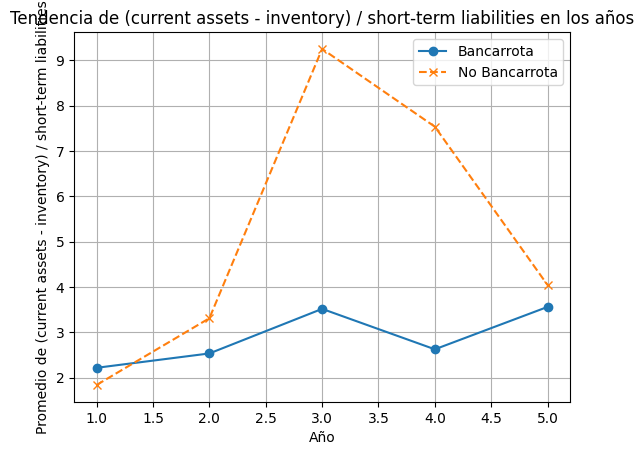

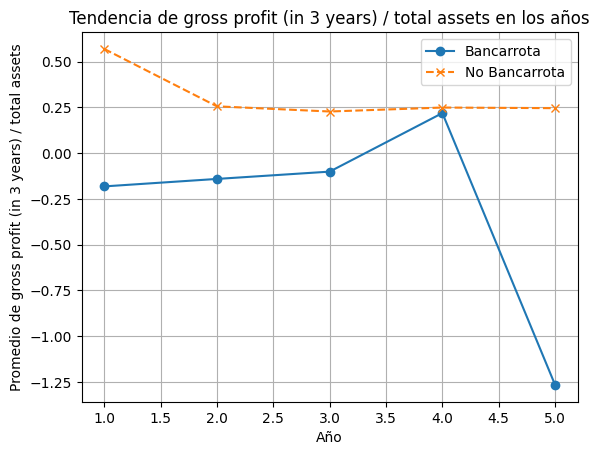

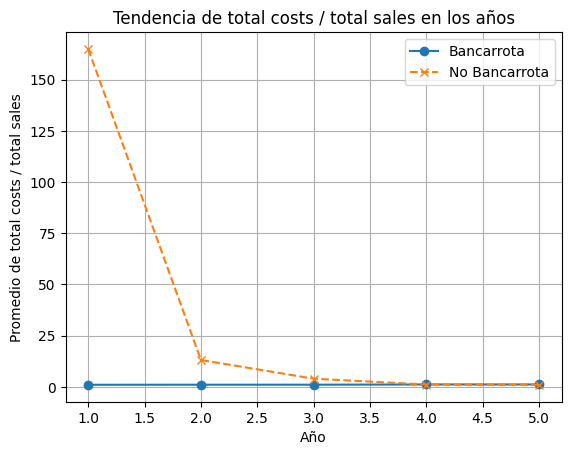

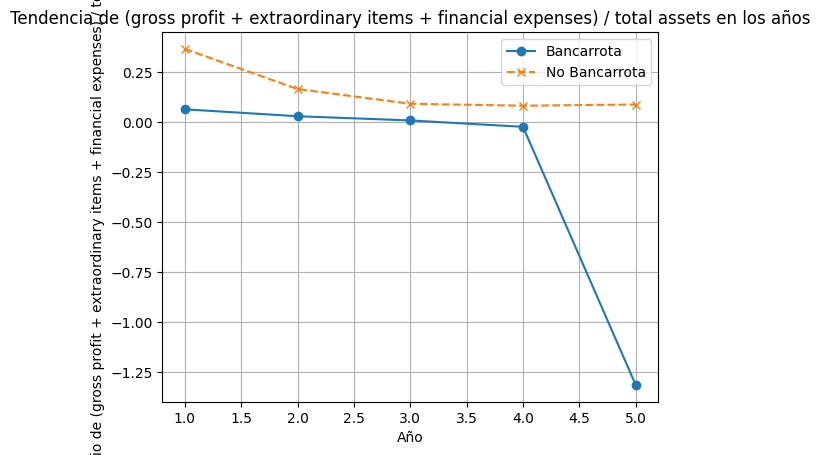

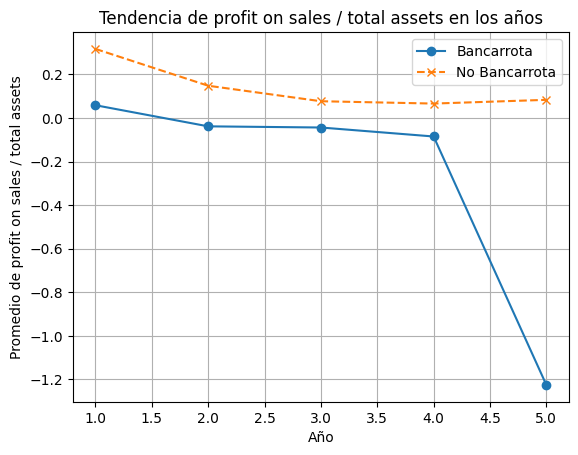

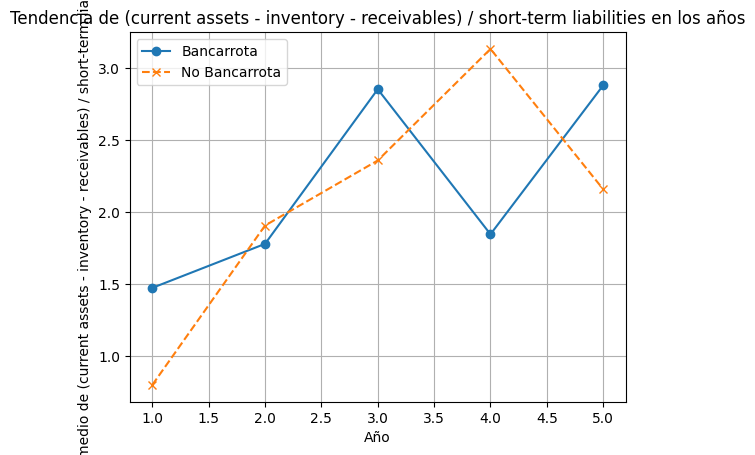

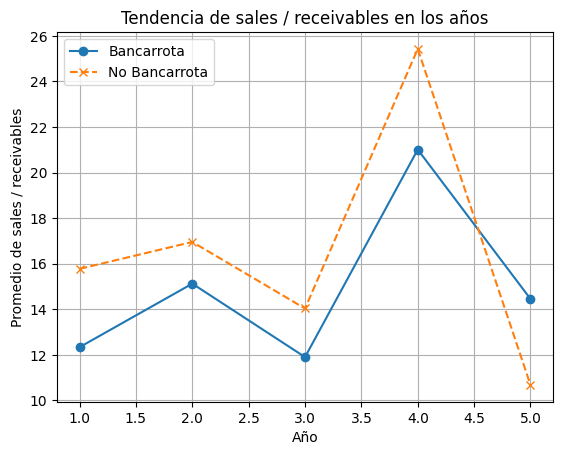

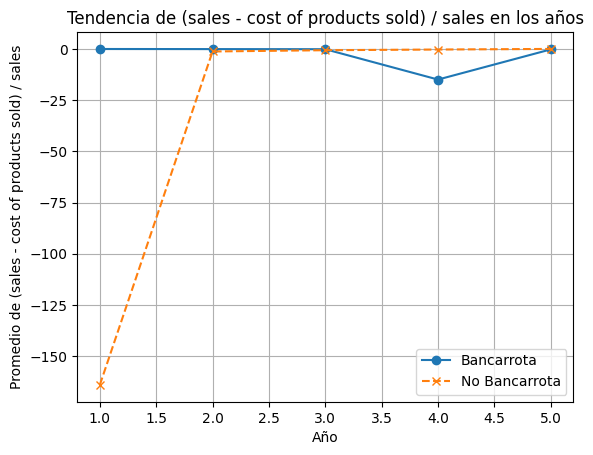

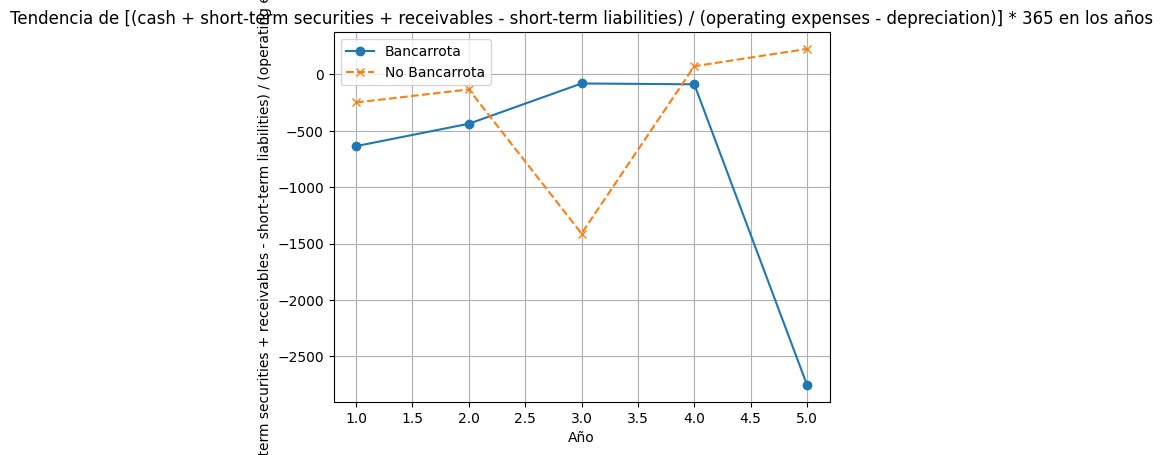

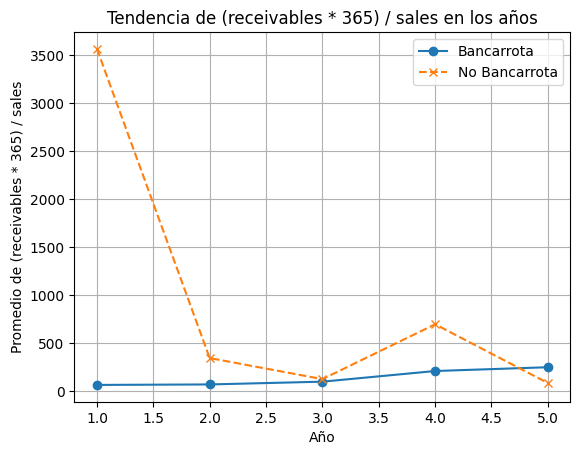

In [ ]:
# Créditos a Tetsuya Sasaki del sitio Kaggle. Adaptamos su código para generar estos gráficos.
df_original_no_bancarrota = df_original[df_original["class"] == 0]
df_original_bancarrota = df_original[df_original["class"] == 1]
df_original_no_bancarrota = df_original_no_bancarrota.rename(columns=data_dict)
df_original_bancarrota = df_original_bancarrota.rename(columns=data_dict)

media_original_no_bancarrota = df_original_no_bancarrota.groupby("year")[importancia['Variable']].mean()
media_original_bancarrota = df_original_bancarrota.groupby("year")[importancia['Variable']].mean()

for variable in importancia['Variable']:
  plt.plot(media_original_bancarrota.index, media_original_bancarrota[variable], marker='o', linestyle='-', label=f'Bancarrota')
  plt.plot(media_original_no_bancarrota.index,media_original_no_bancarrota[variable], marker='x', linestyle='--', label=f'No Bancarrota')
  plt.title(f'Tendencia de {variable} en los años')
  plt.xlabel('Año')
  plt.ylabel(f'Promedio de {variable}')
  plt.legend()
  plt.grid(True)
  plt.show()

Ahora veamos qué pasa si es que rellenamos los vacios por la media (similar al dataframe tratado, pero sin cambiar los outliers) y estandarizamos:

In [ ]:
df_original_media = df_original.copy(deep=True)
df_original_media.fillna(df_original_media.mean(), inplace=True)

In [ ]:
resultados_original_media = procesar_RF(df_original_media, standar=True)

print("Métricas:", resultados_original_media["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_original_media["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_original_media["classification_report"], "\n")

importancia = pd.DataFrame({
    'Variable': df_original.drop(columns=['class']).columns,
    'Importancia': resultados_original_media["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9511610762992997, 'Sensibilidad (recall)': 0.09242144177449169, 'Especificidad': 0.9962176316555136, 'Precisión': 0.5617977528089888, 'F1-Score': 0.15873015873015872} 

Matriz de Confusión:
 [[10272    39]
 [  491    50]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     10311
           1       0.56      0.09      0.16       541

    accuracy                           0.95     10852
   macro avg       0.76      0.54      0.57     10852
weighted avg       0.93      0.95      0.93     10852
 

Importancia de variables: 


,Variable,Importancia
41,(current assets - inventory) / short-term liabilities,0.039141
22,gross profit (in 3 years) / total assets,0.033877
53,total costs / total sales,0.027054
32,profit on sales / total assets,0.022925
36,(current assets - inventory - receivables) / short-term liabilities,0.022204
51,(sales - cost of products sold) / sales,0.022097
55,sales / receivables,0.021639
4,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,0.020231
31,operating expenses / total liabilities,0.020104
40,(receivables * 365) / sales,0.019899


### Datos tratados:

Veamos cómo se comporta el modelo con los datos tratados. Primero, veamos sin estandarizar:

In [ ]:
resultados_tratado = procesar_RF(df_tratado)

print("Métricas:", resultados_tratado["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_tratado["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_tratado["classification_report"], "\n")


importancia = pd.DataFrame({
    'Variable': df_tratado.drop(columns=['class']).columns,
    'Importancia': resultados_tratado["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9503317360855142, 'Sensibilidad (recall)': 0.05730129390018484, 'Especificidad': 0.9971874696925613, 'Precisión': 0.5166666666666667, 'F1-Score': 0.10316139767054909} 

Matriz de Confusión:
 [[10282    29]
 [  510    31]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     10311
           1       0.52      0.06      0.10       541

    accuracy                           0.95     10852
   macro avg       0.73      0.53      0.54     10852
weighted avg       0.93      0.95      0.93     10852
 

Importancia de variables: 


,Variable,Importancia
41,(current assets - inventory) / short-term liabilities,0.042430
22,gross profit (in 3 years) / total assets,0.030751
40,(receivables * 365) / sales,0.024576
53,total costs / total sales,0.022972
36,(current assets - inventory - receivables) / short-term liabilities,0.022725
31,operating expenses / total liabilities,0.022011
4,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,0.021532
55,sales / receivables,0.019938
24,(net profit + depreciation) / total liabilities,0.019921
19,(inventory * 365) / sales,0.019905


Ahora estandarizando:

In [ ]:
resultados_tratado_estandarizado = procesar_RF(df_tratado, standar=True)

print("Métricas:", resultados_tratado_estandarizado["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_tratado_estandarizado["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_tratado_estandarizado["classification_report"], "\n")


importancia = pd.DataFrame({
    'Variable': df_tratado.drop(columns=['class']).columns,
    'Importancia': resultados_tratado_estandarizado["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9506081828234427, 'Sensibilidad (recall)': 0.06099815157116451, 'Especificidad': 0.9972844534962662, 'Precisión': 0.5409836065573771, 'F1-Score': 0.10963455149501662} 

Matriz de Confusión:
 [[10283    28]
 [  508    33]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     10311
           1       0.54      0.06      0.11       541

    accuracy                           0.95     10852
   macro avg       0.75      0.53      0.54     10852
weighted avg       0.93      0.95      0.93     10852
 

Importancia de variables: 


,Variable,Importancia
41,(current assets - inventory) / short-term liabilities,0.042172
22,gross profit (in 3 years) / total assets,0.030968
40,(receivables * 365) / sales,0.024481
36,(current assets - inventory - receivables) / short-term liabilities,0.022971
53,total costs / total sales,0.022965
31,operating expenses / total liabilities,0.021831
4,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,0.021573
19,(inventory * 365) / sales,0.020097
24,(net profit + depreciation) / total liabilities,0.020086
55,sales / receivables,0.019999


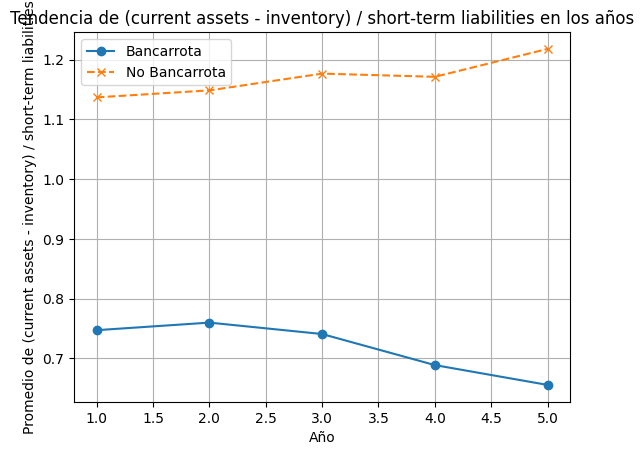

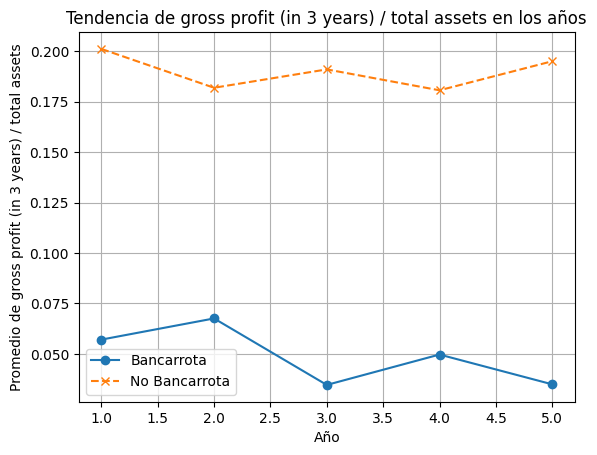

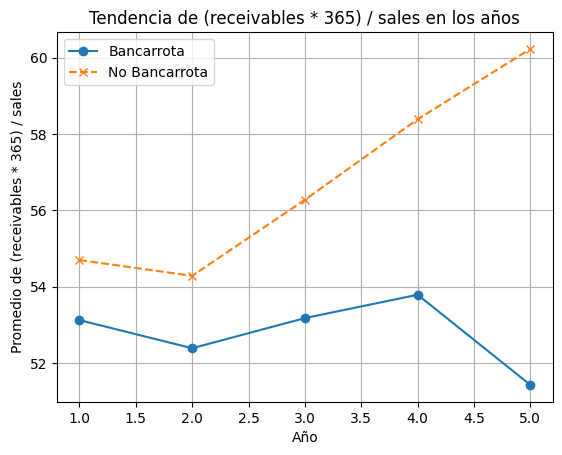

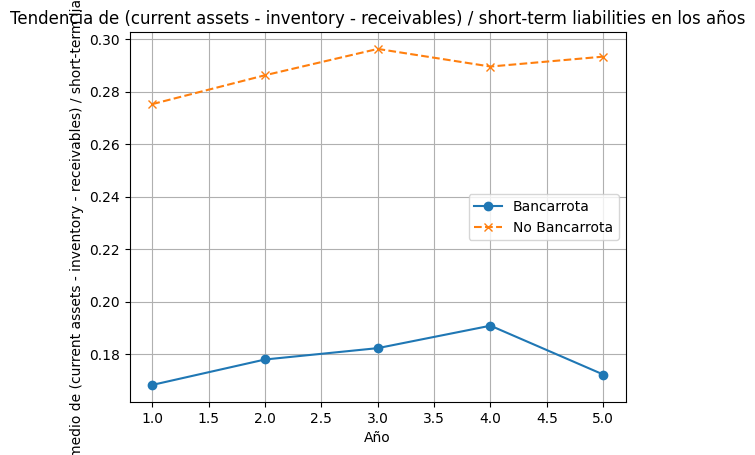

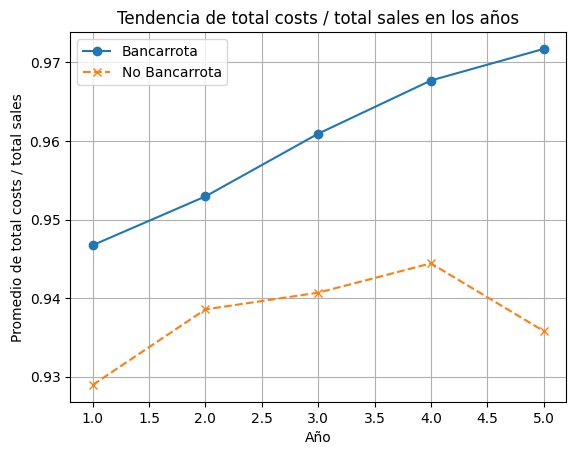

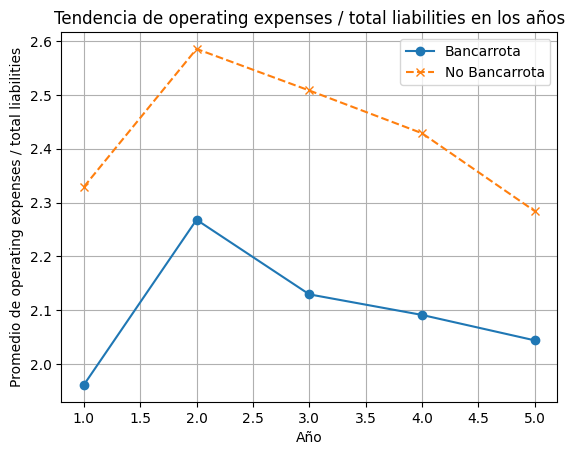

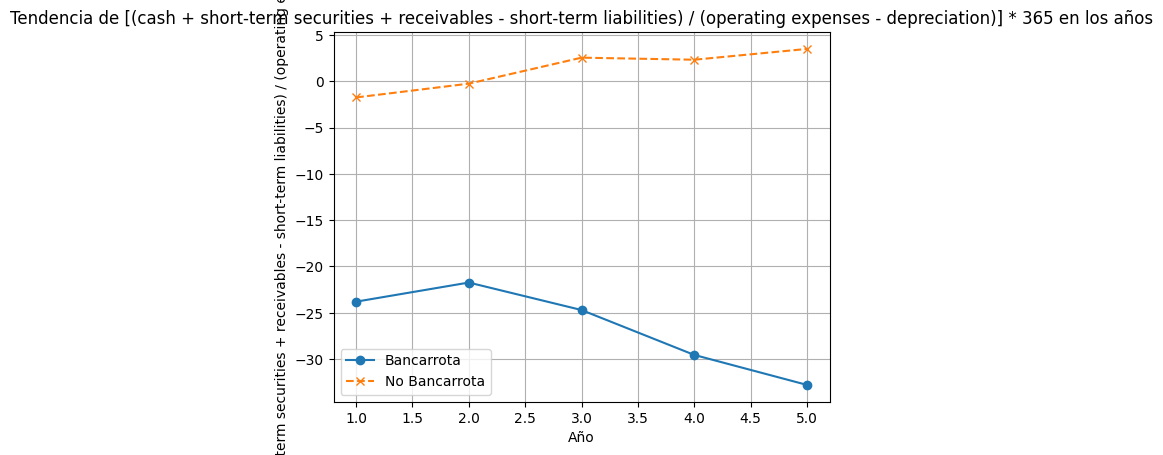

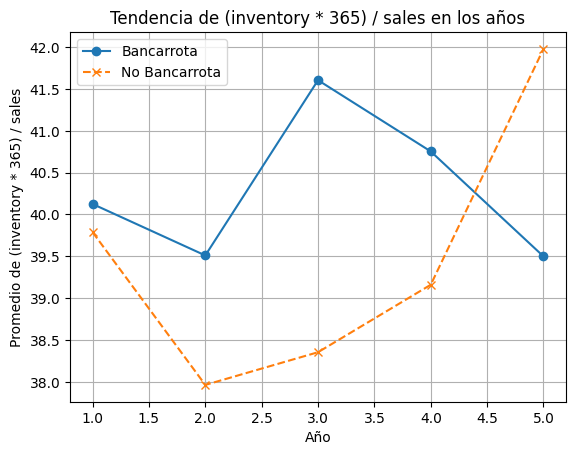

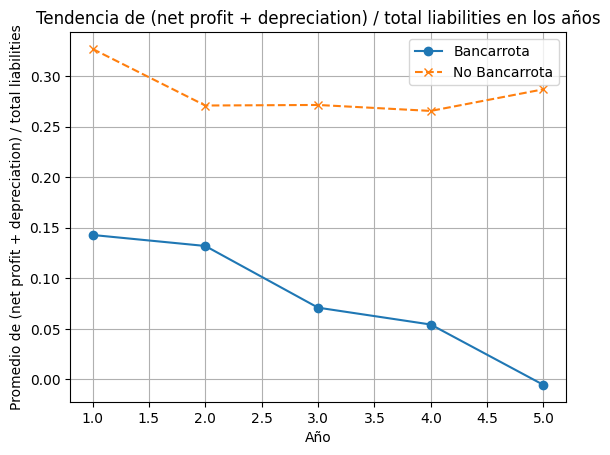

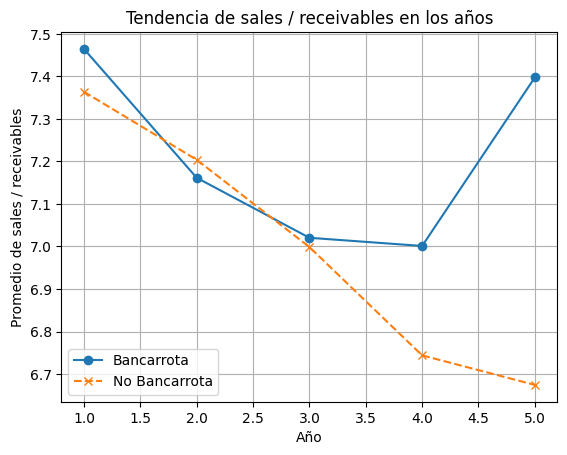

In [ ]:
# Créditos a Tetsuya Sasaki del sitio Kaggle. Adaptamos su código para generar estos gráficos.
df_tratado_no_bancarrota = df_tratado[df_tratado["class"] == 0]
df_tratado_bancarrota = df_tratado[df_tratado["class"] == 1]
df_tratado_no_bancarrota = df_tratado_no_bancarrota.rename(columns=data_dict)
df_tratado_bancarrota = df_tratado_bancarrota.rename(columns=data_dict)

media_tratado_no_bancarrota = df_tratado_no_bancarrota.groupby("year")[importancia['Variable']].mean()
media_tratado_bancarrota = df_tratado_bancarrota.groupby("year")[importancia['Variable']].mean()

for variable in importancia['Variable']:
  plt.plot(media_tratado_bancarrota.index, media_tratado_bancarrota[variable], marker='o', linestyle='-', label=f'Bancarrota')
  plt.plot(media_tratado_no_bancarrota.index,media_tratado_no_bancarrota[variable], marker='x', linestyle='--', label=f'No Bancarrota')
  plt.title(f'Tendencia de {variable} en los años')
  plt.xlabel('Año')
  plt.ylabel(f'Promedio de {variable}')
  plt.legend()
  plt.grid(True)
  plt.show()

## Regresión Logística

Este [modelo](https://https://www.ibm.com/es-es/topics/logistic-regression) también puede resultar útil para el ámbito financiero. Por ejemplo, es utilizado para la detección de fraudes o predicción de abandono, lo cual se puede traucir a la predicción de la bancarrota. A continuación la implementación:

In [ ]:
from sklearn.linear_model import LogisticRegression

def procesar_LR(dataframe, target_column='class', standar=False):
    """
    Entrena y evalua el modelo Random Forest en el dataframe ingresado

    Parametros:
        dataframe (pd.DataFrame)
        target_column (str)

    Retorna:
        dict
    """
    # Definimos X e Y
    X = dataframe.drop(columns=[target_column])
    y = dataframe[target_column]


    # Separamos los datos en entrenamiento y validacion
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

    # Estandarizamos los datos
    if standar:
      scaler = StandardScaler()
      X_train = scaler.fit_transform(X_train)
      X_val = scaler.transform(X_val)

    # Inicializando el modelo
    LR = LogisticRegression(random_state=42, max_iter=10000)

    # Ajustando el modelo
    LR.fit(X_train, y_train)

    # Predección en el conjunto de validación
    y_pred = LR.predict(X_val)

    # Matriz de confusión
    cm = confusion_matrix(y_val, y_pred)
    vn, fp, fn, vp = cm.ravel()

    # Calcular indicadores
    metrics = {
        "Correctitud": (vp + vn) / (vp + vn + fp + fn),
        "Sensibilidad (recall)": vp / (vp + fn),
        "Especificidad": vn / (vn + fp),
        "Precisión": vp / (vp + fp),
        "F1-Score": 2 * (vp / (vp + fp)) * (vp / (vp + fn)) / ((vp / (vp + fp)) + (vp / (vp + fn)))
    }

    # Importancia de las variables
    feature_importances = LR.coef_[0]
    return {
        "metrics": metrics,
        "confusion_matrix": cm,
        "feature_importances": feature_importances,
        "classification_report": classification_report(y_val, y_pred),
    }

### Datos Originales

Primero que nada, para este modelo no se aceptan valores `NaN`, por lo que estos serán reemplazados por la media:

In [ ]:
df_original_media2 = df_original.copy(deep=True)
df_original_media2.fillna(df_original_media2.mean(), inplace=True)

Ahora hagamos la prueba sin estandarizar:

In [ ]:
resultados_original = procesar_LR(df_original_media2)

print("Métricas:", resultados_original["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_original["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_original["classification_report"], "\n")


importancia = pd.DataFrame({
    'Variable': df_original.drop(columns=['class']).columns,
    'Importancia': resultados_original["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9495945447843716, 'Sensibilidad (recall)': 0.011090573012939002, 'Especificidad': 0.9988361943555426, 'Precisión': 0.3333333333333333, 'F1-Score': 0.021466905187835422} 

Matriz de Confusión:
 [[10299    12]
 [  535     6]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     10311
           1       0.33      0.01      0.02       541

    accuracy                           0.95     10852
   macro avg       0.64      0.50      0.50     10852
weighted avg       0.92      0.95      0.93     10852
 

Importancia de variables: 


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Variable,Importancia
36,(current assets - inventory - receivables) / short-term liabilities,0.050324
30,operating expenses / short-term liabilities,0.045576
31,operating expenses / total liabilities,0.045223
7,book value of equity / total liabilities,0.034409
44,EBITDA (profit on operating activities - depreciation) / sales,0.023288
38,profit on operating activities / sales,0.019883
28,(gross profit + interest) / sales,0.018696
21,net profit / sales,0.013068
48,equity / fixed assets,0.009151
18,gross profit / sales,0.008909


Notamos que el modelo no logra converger con las iteraciones ingresadas (10000). Esto es normal puesto que la regresión logística no logra capturar bien relaciones complejas o no lineales de datos. Por lo tanto, intentemos estandarizando:

In [ ]:
resultados_original_estandarizado = procesar_LR(df_original_media2, standar=True)

print("Métricas:", resultados_original_estandarizado["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_original_estandarizado["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_original_estandarizado["classification_report"], "\n")


importancia = pd.DataFrame({
    'Variable': df_original.drop(columns=['class']).columns,
    'Importancia': resultados_original_estandarizado["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9503317360855142, 'Sensibilidad (recall)': 0.009242144177449169, 'Especificidad': 0.9997090485888857, 'Precisión': 0.625, 'F1-Score': 0.018214936247723135} 

Matriz de Confusión:
 [[10308     3]
 [  536     5]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     10311
           1       0.62      0.01      0.02       541

    accuracy                           0.95     10852
   macro avg       0.79      0.50      0.50     10852
weighted avg       0.93      0.95      0.93     10852
 

Importancia de variables: 


,Variable,Importancia
43,EBITDA (profit on operating activities - depreciation) / total assets,4.137172
24,(net profit + depreciation) / total liabilities,0.936259
31,operating expenses / total liabilities,0.835555
30,operating expenses / short-term liabilities,0.816881
36,(current assets - inventory - receivables) / short-term liabilities,0.495657
33,total sales / total assets,0.368029
29,(current liabilities * 365) / cost of products sold,0.346548
23,(equity - share capital) / total assets,0.331561
28,(gross profit + interest) / sales,0.289669
48,equity / fixed assets,0.244776


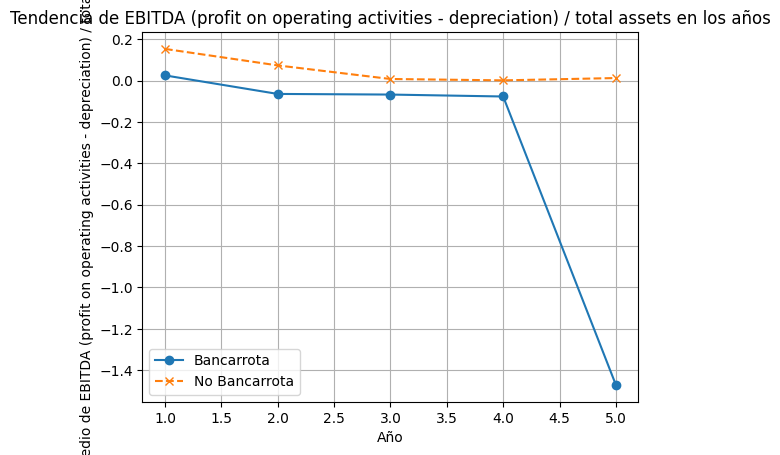

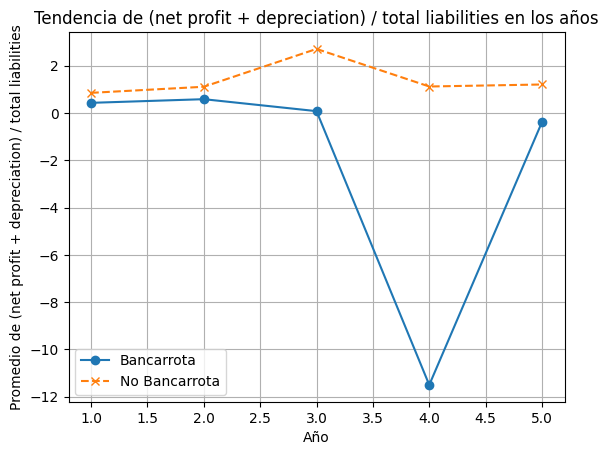

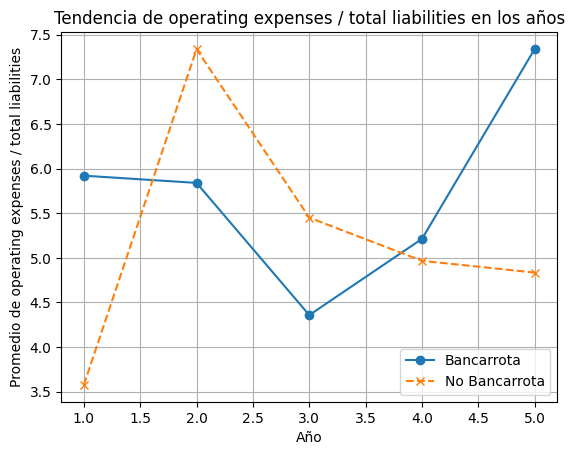

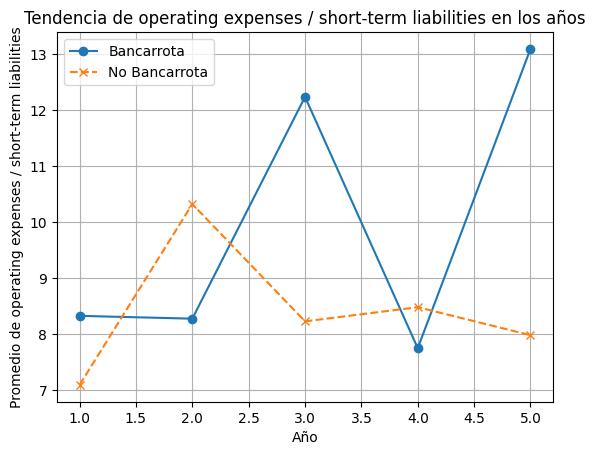

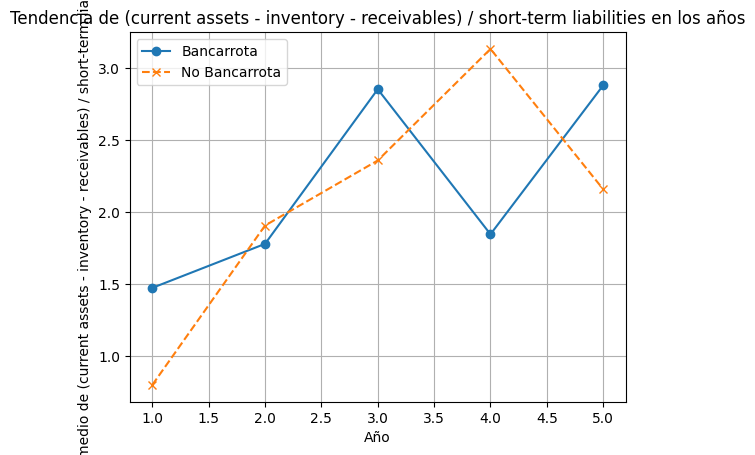

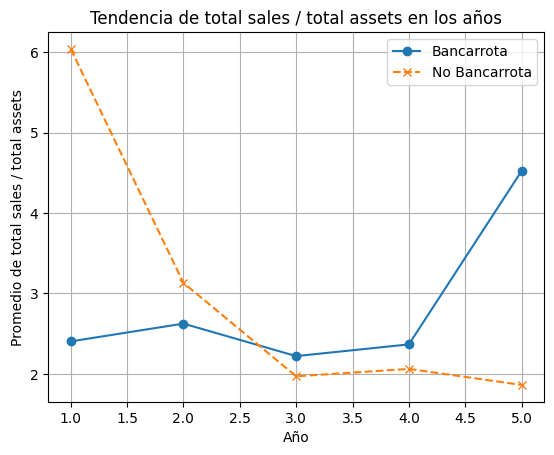

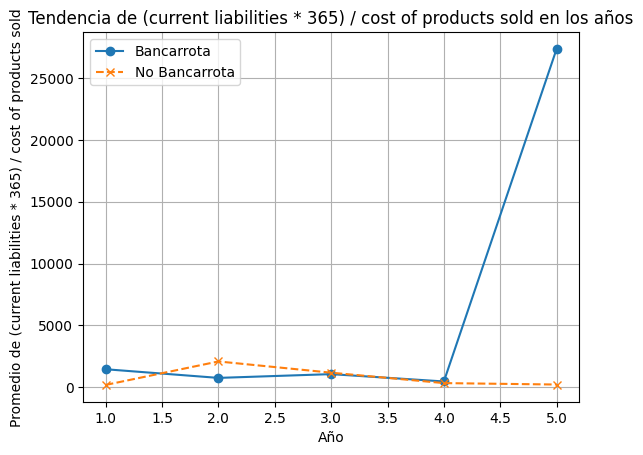

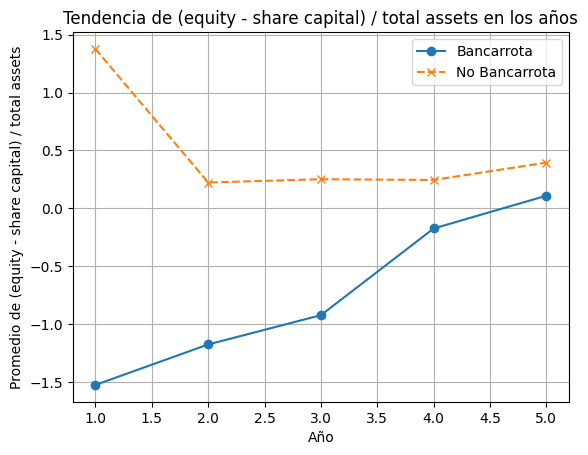

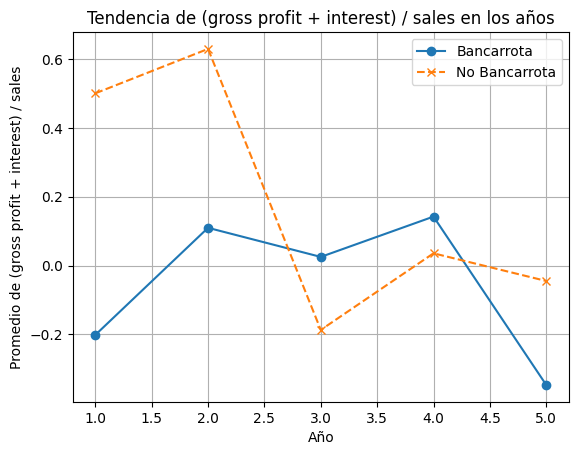

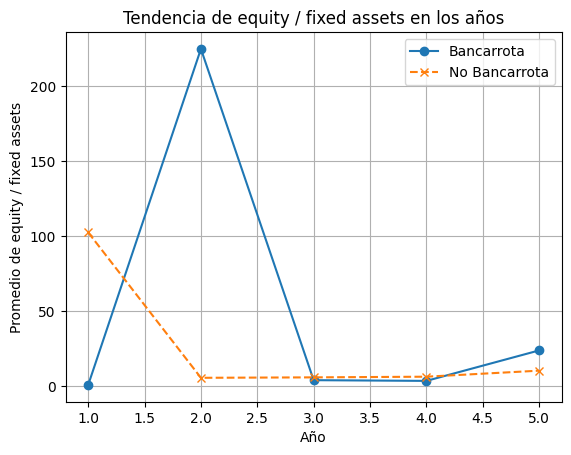

In [ ]:
# Créditos a Tetsuya Sasaki del sitio Kaggle. Adaptamos su código para generar estos gráficos.
df_original_no_bancarrota = df_original[df_original["class"] == 0]
df_original_bancarrota = df_original[df_original["class"] == 1]
df_original_no_bancarrota = df_original_no_bancarrota.rename(columns=data_dict)
df_original_bancarrota = df_original_bancarrota.rename(columns=data_dict)

media_original_no_bancarrota = df_original_no_bancarrota.groupby("year")[importancia['Variable']].mean()
media_original_bancarrota = df_original_bancarrota.groupby("year")[importancia['Variable']].mean()

for variable in importancia['Variable']:
  plt.plot(media_original_bancarrota.index, media_original_bancarrota[variable], marker='o', linestyle='-', label=f'Bancarrota')
  plt.plot(media_original_no_bancarrota.index,media_original_no_bancarrota[variable], marker='x', linestyle='--', label=f'No Bancarrota')
  plt.title(f'Tendencia de {variable} en los años')
  plt.xlabel('Año')
  plt.ylabel(f'Promedio de {variable}')
  plt.legend()
  plt.grid(True)
  plt.show()

### Datos Tratados

En este caso, no tenemos `NaN` por el tratamiento entregado. Por lo tanto, veamos primero sin estandarizar:

In [ ]:
resultados_tratado = procesar_LR(df_tratado)

print("Métricas:", resultados_tratado["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_tratado["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_tratado["classification_report"], "\n")


importancia = pd.DataFrame({
    'Variable': df_original.drop(columns=['class']).columns,
    'Importancia': resultados_tratado["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9502395871728714, 'Sensibilidad (recall)': 0.0018484288354898336, 'Especificidad': 1.0, 'Precisión': 1.0, 'F1-Score': 0.0036900369003690036} 

Matriz de Confusión:
 [[10311     0]
 [  540     1]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     10311
           1       1.00      0.00      0.00       541

    accuracy                           0.95     10852
   macro avg       0.98      0.50      0.49     10852
weighted avg       0.95      0.95      0.93     10852
 

Importancia de variables: 


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Variable,Importancia
2,working capital / total assets,0.453877
36,(current assets - inventory - receivables) / short-term liabilities,0.404299
44,EBITDA (profit on operating activities - depreciation) / sales,0.365918
43,EBITDA (profit on operating activities - depreciation) / total assets,0.270505
33,total sales / total assets,0.268280
11,gross profit / short-term liabilities,0.227853
16,total assets / total liabilities,0.159182
59,year,0.156535
3,current assets / short-term liabilities,0.143706
30,operating expenses / short-term liabilities,0.136135


Nuevamente el modelo no pudo converger, aunque los resultados son prometedores. Veamos cómo se comportan las variables más importantes:

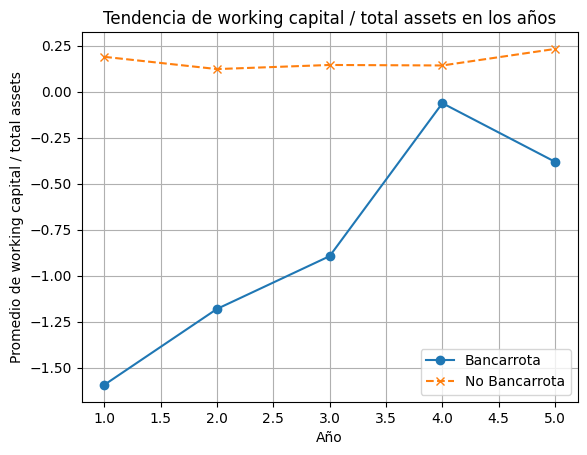

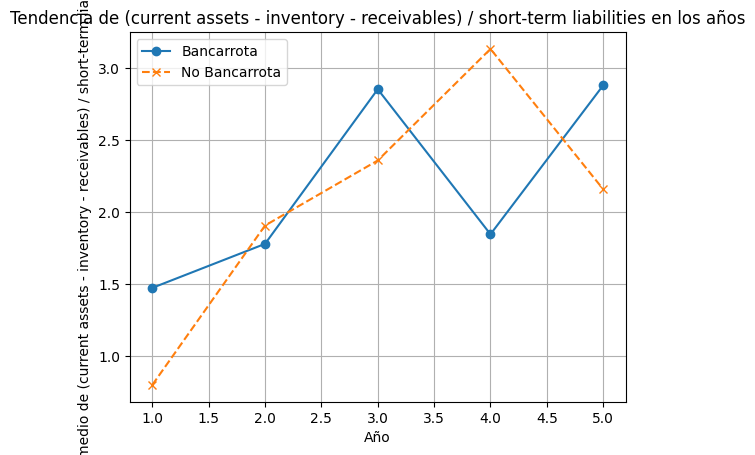

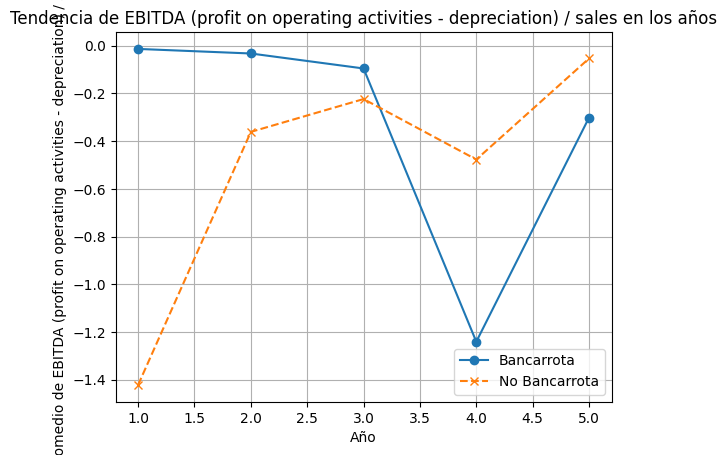

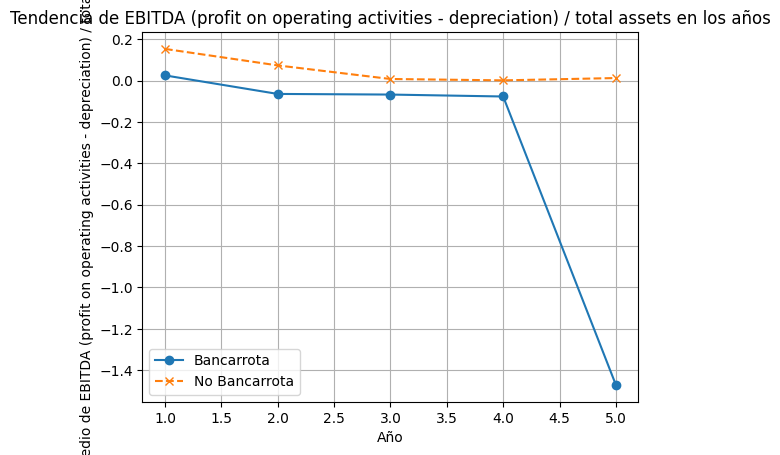

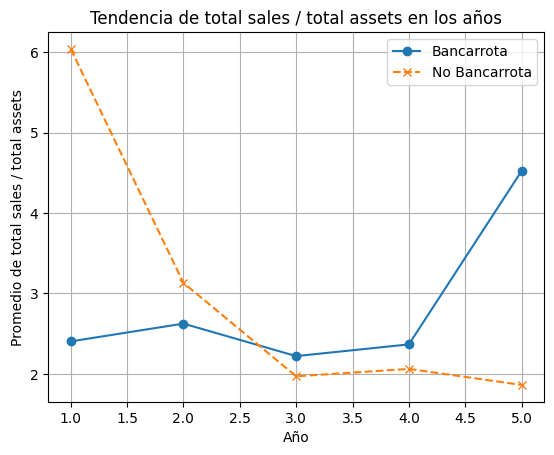

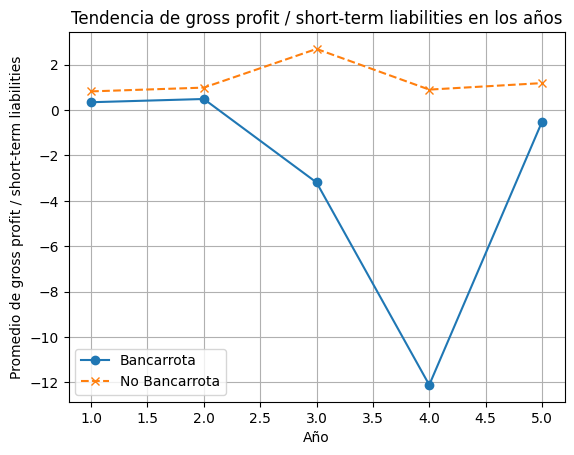

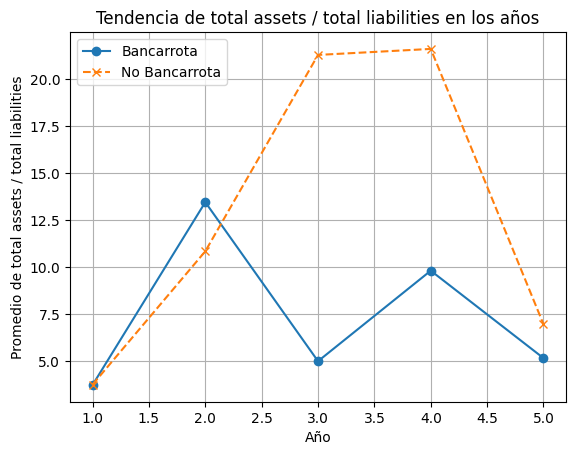

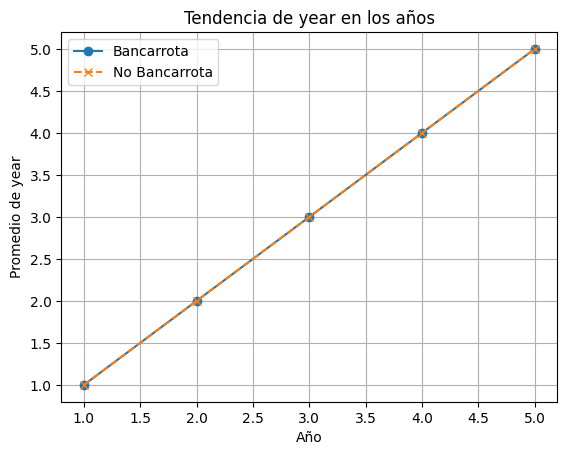

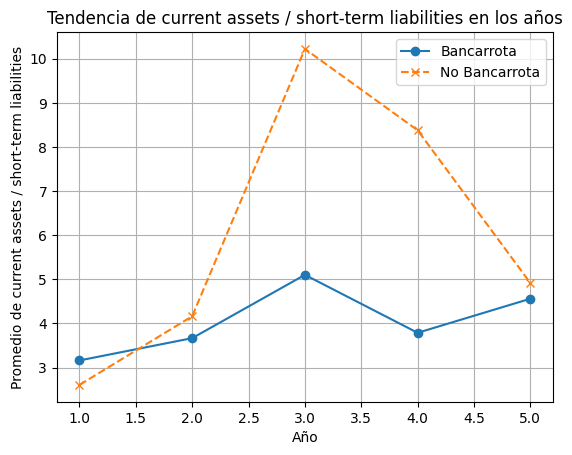

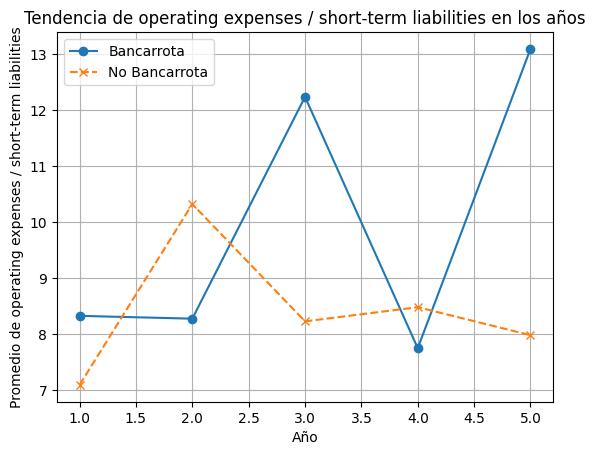

In [ ]:
# Créditos a Tetsuya Sasaki del sitio Kaggle. Adaptamos su código para generar estos gráficos.
df_original_no_bancarrota = df_original[df_original["class"] == 0]
df_original_bancarrota = df_original[df_original["class"] == 1]
df_original_no_bancarrota = df_original_no_bancarrota.rename(columns=data_dict)
df_original_bancarrota = df_original_bancarrota.rename(columns=data_dict)

media_original_no_bancarrota = df_original_no_bancarrota.groupby("year")[importancia['Variable']].mean()
media_original_bancarrota = df_original_bancarrota.groupby("year")[importancia['Variable']].mean()

for variable in importancia['Variable']:
  plt.plot(media_original_bancarrota.index, media_original_bancarrota[variable], marker='o', linestyle='-', label=f'Bancarrota')
  plt.plot(media_original_no_bancarrota.index,media_original_no_bancarrota[variable], marker='x', linestyle='--', label=f'No Bancarrota')
  plt.title(f'Tendencia de {variable} en los años')
  plt.xlabel('Año')
  plt.ylabel(f'Promedio de {variable}')
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
resultados_tratado_estandarizado = procesar_LR(df_tratado, standar=True)

print("Métricas:", resultados_tratado_estandarizado["metrics"], "\n")
print("Matriz de Confusión:\n", resultados_tratado_estandarizado["confusion_matrix"], "\n")
print("Reporte de Clasificación:\n", resultados_tratado_estandarizado["classification_report"], "\n")


importancia = pd.DataFrame({
    'Variable': df_original.drop(columns=['class']).columns,
    'Importancia': resultados_tratado_estandarizado["feature_importances"]
})
importancia = importancia.sort_values(by=['Importancia'], ascending=False)
importancia['Variable'] = importancia['Variable'].map(data_dict)
importancia = importancia.head(10) # Para ver la importancia de todas las variables, eliminar esta linea
print("Importancia de variables: ")
display(importancia.style.background_gradient(cmap='Blues'))

Métricas: {'Correctitud': 0.9502395871728714, 'Sensibilidad (recall)': 0.014787430683918669, 'Especificidad': 0.9993211133740665, 'Precisión': 0.5333333333333333, 'F1-Score': 0.02877697841726619} 

Matriz de Confusión:
 [[10304     7]
 [  533     8]] 

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     10311
           1       0.53      0.01      0.03       541

    accuracy                           0.95     10852
   macro avg       0.74      0.51      0.50     10852
weighted avg       0.93      0.95      0.93     10852
 

Importancia de variables: 


,Variable,Importancia
29,(current liabilities * 365) / cost of products sold,1.077342
30,operating expenses / short-term liabilities,0.409710
44,EBITDA (profit on operating activities - depreciation) / sales,0.216711
33,total sales / total assets,0.209922
3,current assets / short-term liabilities,0.187804
59,year,0.186211
16,total assets / total liabilities,0.139447
48,equity / fixed assets,0.115004
39,rotation receivables + inventory turnover in days,0.112252
2,working capital / total assets,0.108043


# Conclusiones

## Comparación entre modelos:

Basándonos en los resultados obtenidos, el modelo de Random Forest mostró un desempeño consistentemente superior en comparación con la Regresión Logística en términos de métricas como la Sensibilidad (recall) y el F1-Score, aunque ambos modelos presentan limitaciones significativas en la sensibilidad, lo que indica un desafío para identificar correctamente los casos positivos, es decir, la bancarrota. De todas formas, esto último puede ser explicado por la gran cantidad de datos de empresas que NO cayeron en bancarrota versus las que sí lo hicieron (41314
y 2091 respectivamente)

Random Forest logró una correctitud que oscila entre 95.0% y 95.2% en los distintos escenarios. Su F1-Score, aunque bajo, alcanzó su mejor valor (0.185) con datos originales estandarizados. Sin embargo, este modelo mostró una alta especificidad (~99.6-99.7%), lo que evidencia que es muy eficaz para identificar correctamente los casos negativos, pero no logra balancear este desempeño con la identificación de los positivos.

En contraste, la Regresión Logística presentó valores de F1-Score considerablemente más bajos, con un máximo de 0.028. Esto sugiere que este modelo no es adecuado para la problemática en cuestión, ya que tiene una sensibilidad casi nula (~1% en algunos escenarios), fallando en gran medida en la detección de casos positivos. Cabe mencionar que, en el caso de los datos tratados sin estandarizar, el modelo logró un 100% de precisión y especificidad, a pesar de no lograr converger. Esto puede sugerir que con una alta capacidad computacional, este caso podría ser favorable.

A pesar de las limitaciones, Random Forest se selecciona como el modelo final debido a su mejor equilibrio entre las métricas y su capacidad superior en comparación con la Regresión Logística. Es importante recalcar que ambos modelos sufren de un desequilibrio significativo en la clasificación, lo que podría mejorarse, por ejemplo, optimizando hiperparámetros o usando sobremuestreo para equilibrar la proporción de clases en los datos. Además, se podría estudiar un ensamblaje de los modelos que rescate las características positivas de cada uno para obtener el "modelo definitivo".

## Aplicación a la problemática planteada:

El objetivo inicial del proyecto era abordar un problema de clasificación binaria (bancarrota o no). Con los modelos implementados, es evidente que Random Forest, aunque no perfecto, es una herramienta más confiable para la toma de decisiones. La alta especificidad sugiere que el modelo es adecuado para evitar falsos positivos, lo cual es útil a la hora de "desactivar alarmas" de una empresa que cree que quebrará. Sin embargo, en este contexto destaca la necesidad de precisión, es decir, es incluso más importante lograr "activar alarmas" para poder aplicar medidas cuando una empresa se predice que caerá en bancarrota.

Se sigue recalcando que el modelo no posee buena precisión, pero, en realidad, los resultados indican que, al mantener los datos originales y estandarizarlos, se logra un 62% de precisión. Por lo que se logra parcialemente crear una herramienta para predecir la bancarrota de una empresa. Para mejorar su aplicación práctica, es crucial la abordar la baja sensibilidad del modelo. Esto se podría conseguir optimizando hiperparámetros o cargando una mayor cantidad de datos de empresas que hayan caído en bancarrota.